# P0480 PLMN Z-Score Anomaly Detection

`260611_analyze.ipynb`와 동일한 데이터 소스를 사용하여, **P0480** PLMN의 전체 시계열에 대해 z-score 기반 이상 탐지를 수행하고 결과를 시각화합니다.

- **방법**: 각 메트릭(M971, M658, …)별로 전체 시계열의 평균·표준편차를 구한 뒤, `|z| > threshold` 인 시점을 anomaly로 표시
- **기본 threshold**: 3 (표준편차 3배 이상 벗어난 값)

In [13]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

TARGET_PLMN = "P0480"
Z_THRESHOLD = 3.0
DATA_DIR = "../data"
SAVE_DIR = "../results"

## 1. 데이터 로드 (P0480만)

In [7]:
csv_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".csv"))

df_list = []
for file in csv_files:
    path = os.path.join(DATA_DIR, file)
    temp_df = pd.read_csv(path)
    temp_df = temp_df[temp_df["PLMN"] == TARGET_PLMN]
    if not temp_df.empty:
        df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values("time").reset_index(drop=True)
df["time"] = pd.to_datetime(df["time"])

metric_cols = [c for c in df.columns if c not in ("time", "PLMN")]

print(f"PLMN: {TARGET_PLMN}")
print(f"기간: {df['time'].min()} ~ {df['time'].max()}")
print(f"행 수: {len(df):,}, 메트릭 수: {len(metric_cols)}")
df.head()

PLMN: P0480
기간: 2026-04-29 15:00:00+00:00 ~ 2026-06-09 14:55:00+00:00
행 수: 11,805, 메트릭 수: 46


,time,PLMN,M971,M658,M696,M855,M162,M037,M430,M185,M965,M874,M843,M494,M972,M779,M474,M265,M164,M899,M348,M204,M520,M392,M318,M736,M516,M336,M786,M378,M529,M104,M688,M991,M767,M609,M719,M904,M452,M362,M490,M841,M419,M618,M475,M238,M029,M610
0,2026-04-29 15:00:00+00:00,P0480,3898,26,1085,0,0,0,0,45,15,149,0,0,0,0,0,2,0,9,0,0,2589,0,0.0,0,0,0,24,26,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0
1,2026-04-29 15:05:00+00:00,P0480,4014,32,1095,0,0,0,0,43,4,153,0,0,0,0,0,6,0,9,0,0,2701,0,0.0,0,1,0,26,32,0,1,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0
2,2026-04-29 15:10:00+00:00,P0480,3965,27,1114,0,0,0,0,44,28,146,0,0,0,0,0,2,0,8,0,0,2609,0,0.0,0,1,0,23,27,0,0,0,0,0,9,0,2,0,0,0,0,0,0,0,0,0,0
3,2026-04-29 15:15:00+00:00,P0480,3839,22,982,0,0,0,0,43,3,165,0,0,0,0,0,4,0,4,0,0,2620,0,0.0,0,0,0,18,22,0,1,0,0,0,10,0,3,0,0,0,0,0,0,0,0,0,0
4,2026-04-29 15:20:00+00:00,P0480,3929,20,1101,0,0,0,0,47,15,168,0,0,0,6,0,3,0,5,0,0,2589,0,0.0,0,0,0,24,20,1,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0


## 2. Z-Score 이상 탐지

In [9]:
def detect_zscore_anomalies(series: pd.Series, threshold: float = Z_THRESHOLD) -> pd.Series:
    """전체 시계열 기준 z-score를 계산하고, |z| > threshold 인 시점을 True로 반환."""
    mean = series.mean()
    std = series.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z_scores = (series - mean) / std
    return z_scores.abs() > threshold


zscore_df = pd.DataFrame(index=df.index)
anomaly_mask = pd.DataFrame(index=df.index)

for col in metric_cols:
    zscore_df[col] = (df[col] - df[col].mean()) / df[col].std(ddof=0)
    anomaly_mask[col] = detect_zscore_anomalies(df[col], Z_THRESHOLD)

# 시점별 anomaly 메트릭 개수
df["anomaly_count"] = anomaly_mask.sum(axis=1)
df["is_anomaly"] = df["anomaly_count"] > 0

anomaly_summary = (
    anomaly_mask.sum()
    .reset_index(name="anomaly_count")
    .rename(columns={"index": "metric"})
    .sort_values("anomaly_count", ascending=False)
)

print(f"anomaly 시점 수: {df['is_anomaly'].sum():,} / {len(df):,}")
print(f"anomaly 비율: {df['is_anomaly'].mean():.2%}")
anomaly_summary.head(10)

anomaly 시점 수: 3,027 / 11,805
anomaly 비율: 25.64%


,metric,anomaly_count
38,M490,650
42,M475,418
10,M843,322
23,M736,296
44,M029,256
24,M516,214
39,M841,186
17,M899,160
35,M904,147
9,M874,139


## 3. 전체 시계열 시각화 (anomaly 표시)

`260611_analyze.ipynb`의 trend plot과 동일하게 모든 메트릭을 한 그래프에 그린 뒤, **anomaly로 판단된 각 feature의 실제 값**을 빨간 점으로 표시합니다.

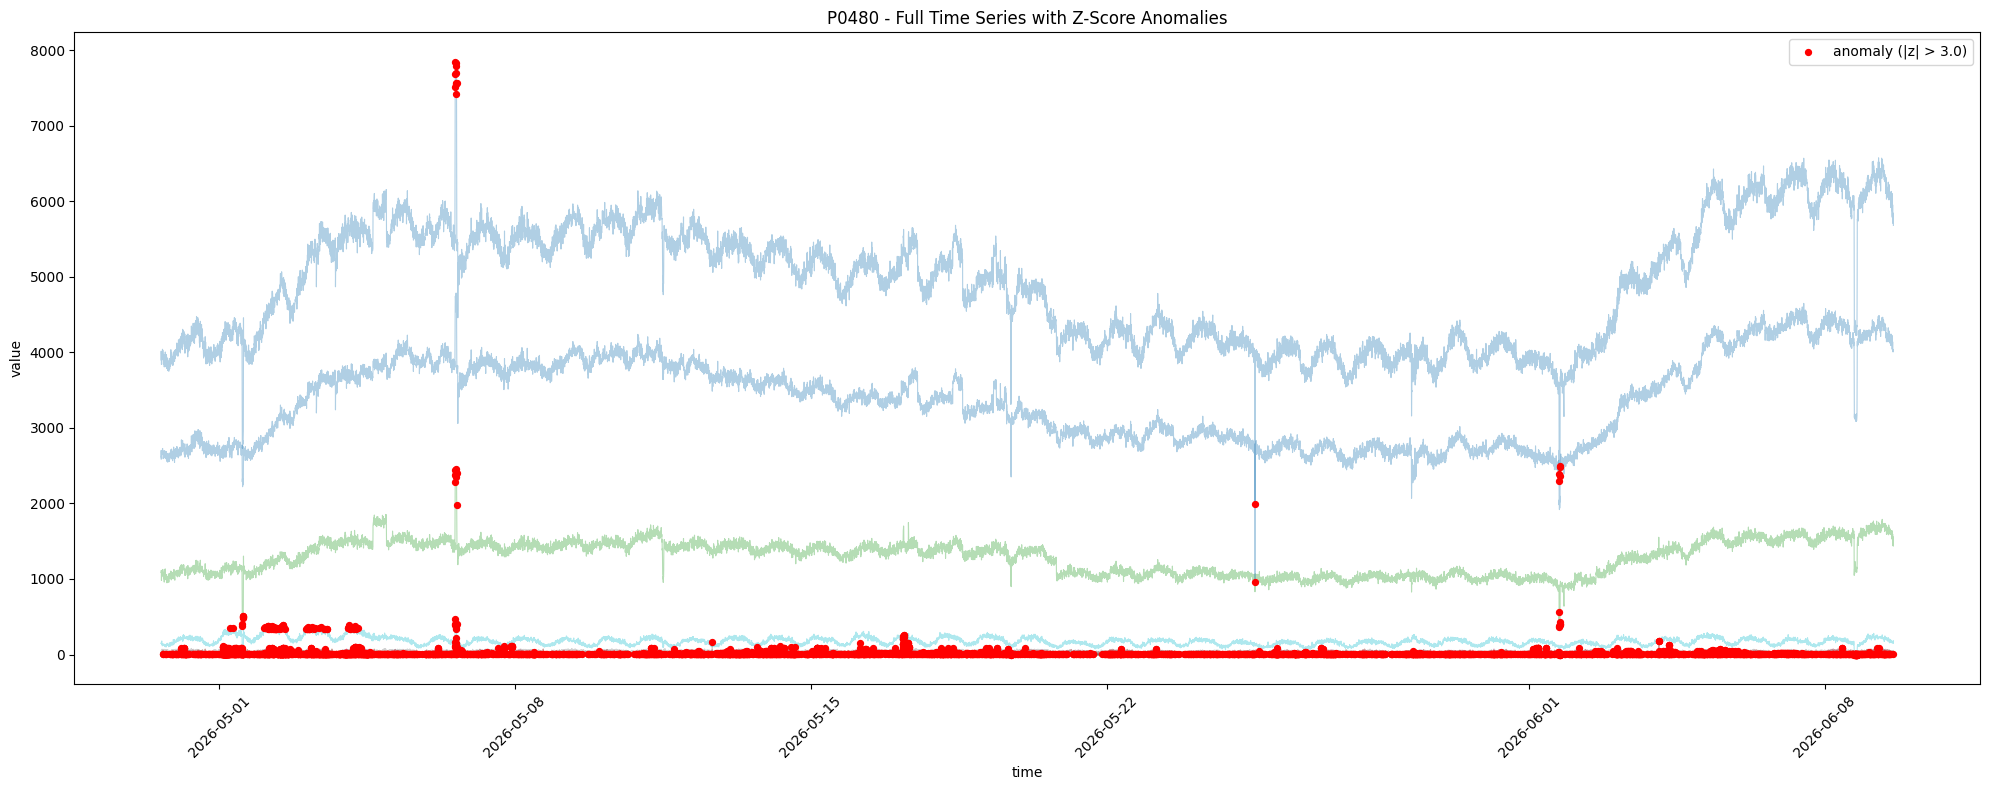

In [10]:
fig, ax = plt.subplots(figsize=(20, 8))

anomaly_labeled = False
for col in metric_cols:
    ax.plot(df["time"], df[col], alpha=0.35, linewidth=0.8)

    anomaly_idx = df.index[anomaly_mask[col]]
    if len(anomaly_idx) == 0:
        continue

    ax.scatter(
        df.loc[anomaly_idx, "time"],
        df.loc[anomaly_idx, col],
        color="red",
        s=18,
        zorder=5,
        label=f"anomaly (|z| > {Z_THRESHOLD})" if not anomaly_labeled else None,
    )
    anomaly_labeled = True

ax.set_title(f"{TARGET_PLMN} - Full Time Series with Z-Score Anomalies")
ax.set_xlabel("time")
ax.set_ylabel("value")
if anomaly_labeled:
    ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 4. 메트릭별 시계열 + anomaly 상세 플롯

anomaly가 한 번이라도 발생한 메트릭에 대해 개별 시계열을 그립니다.

anomaly가 있는 메트릭 수: 32


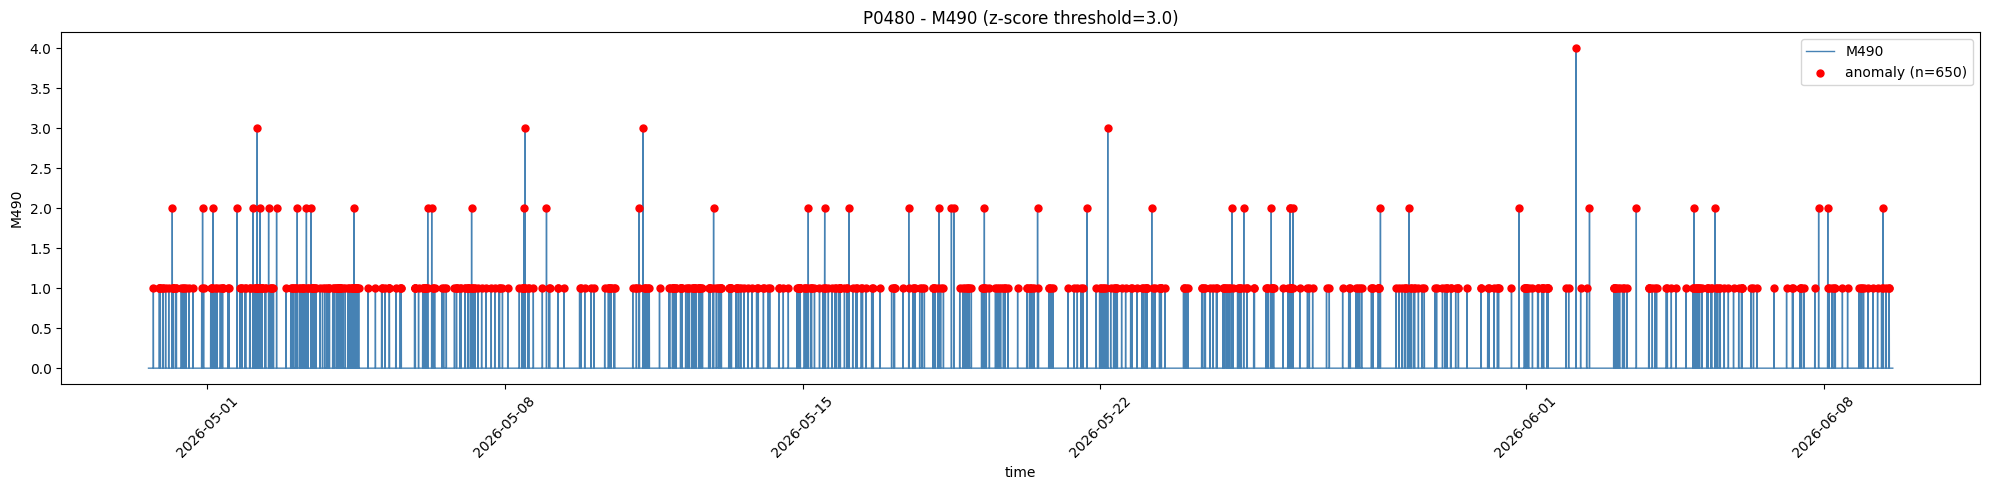

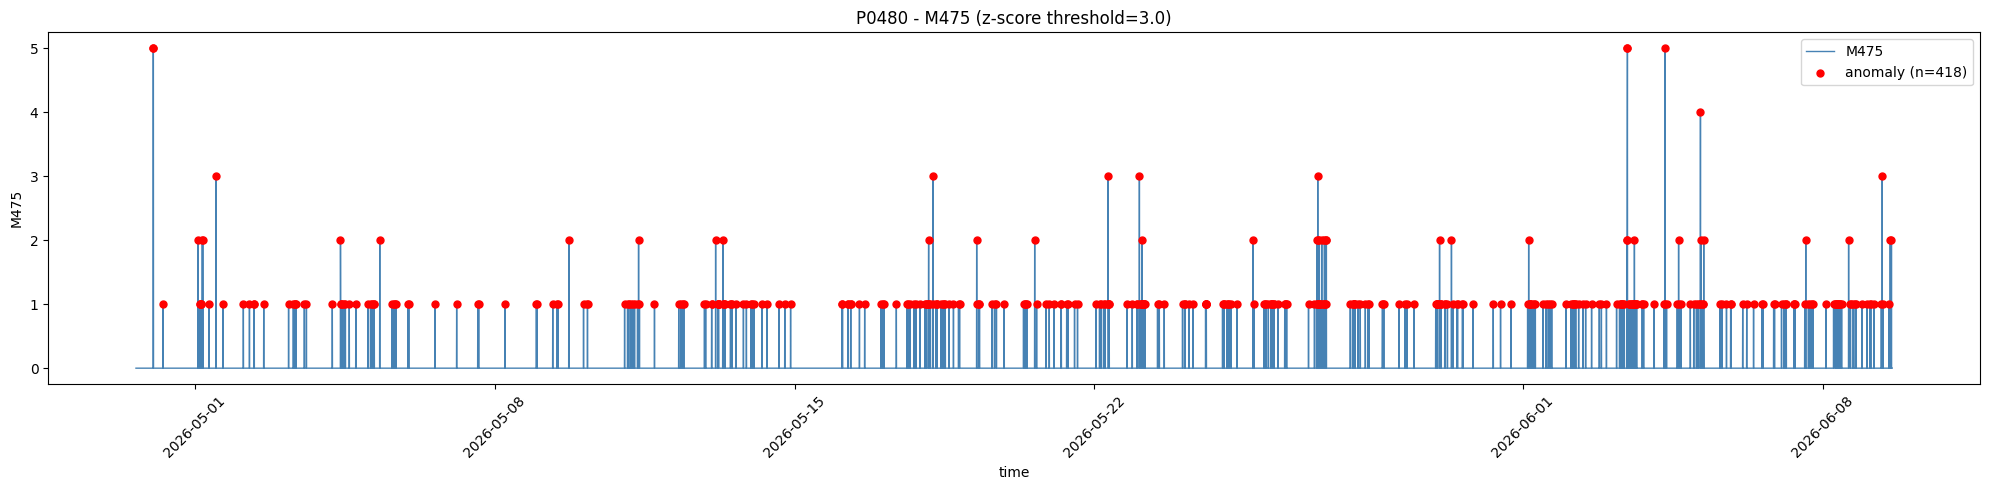

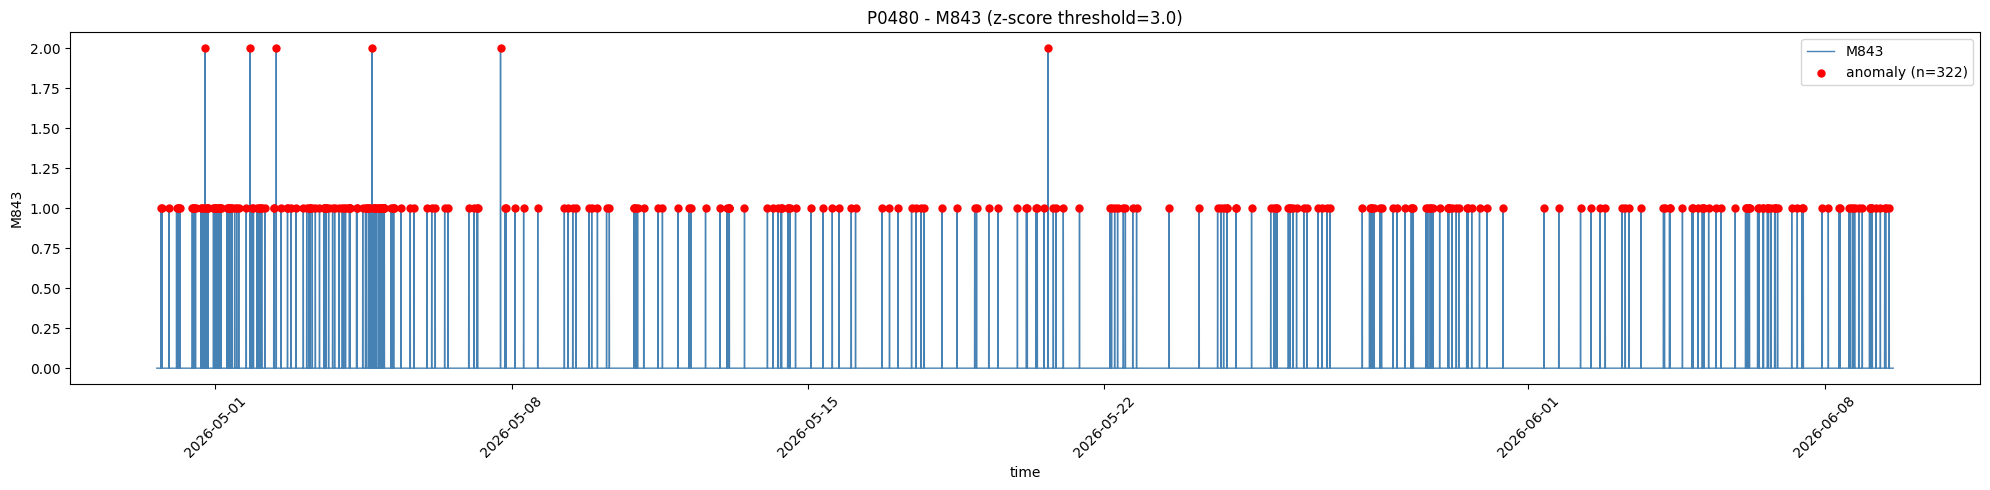

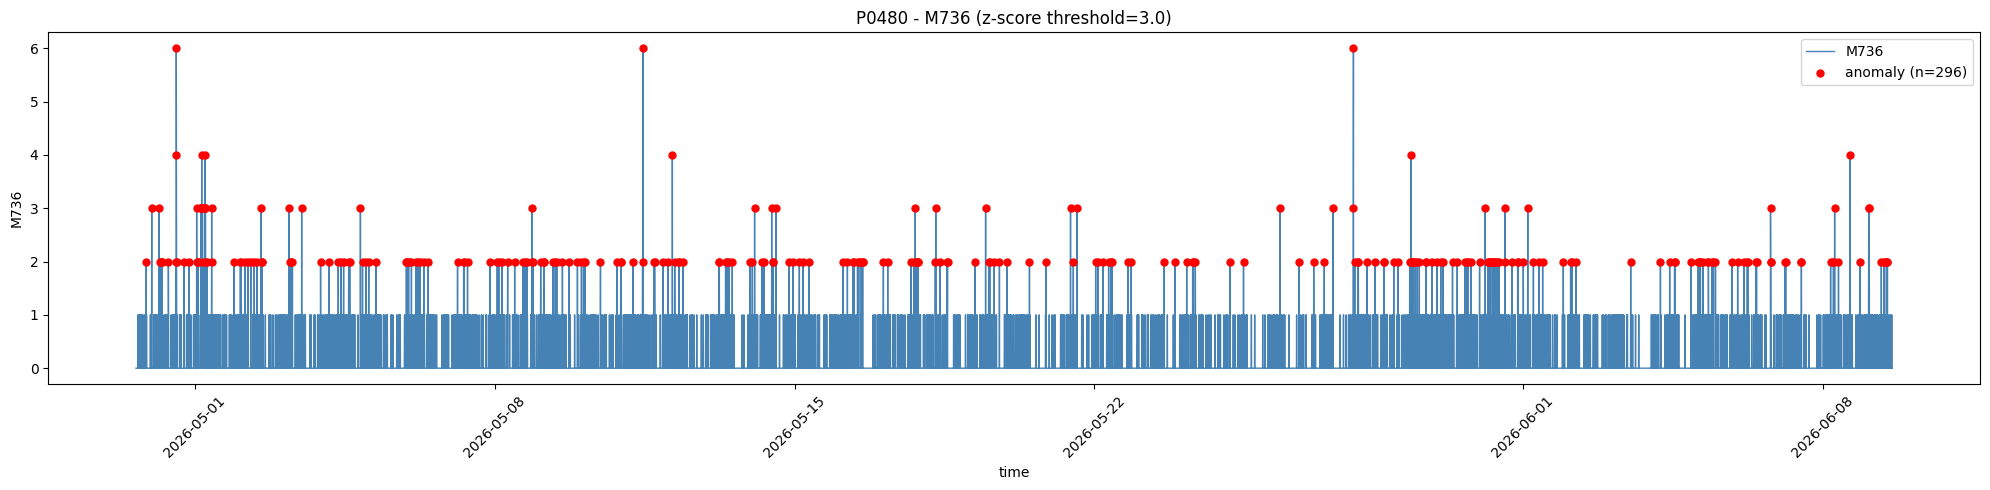

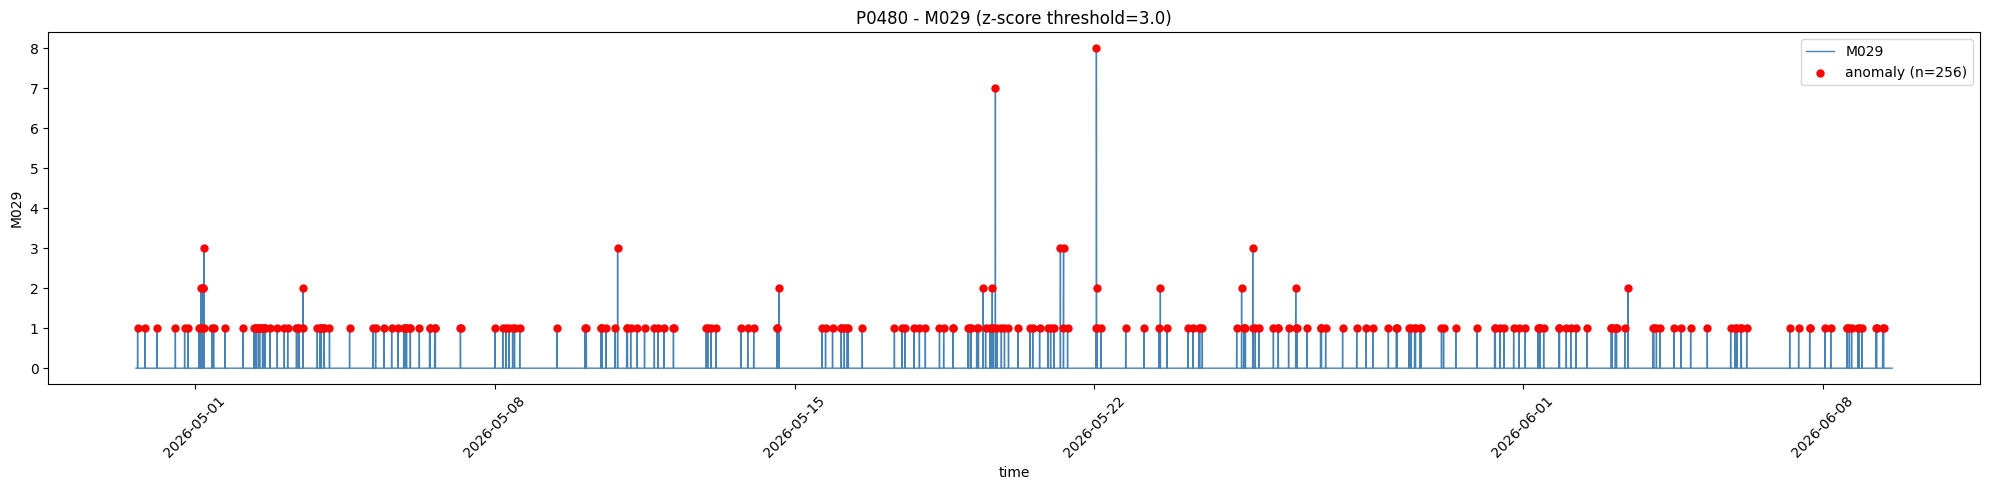

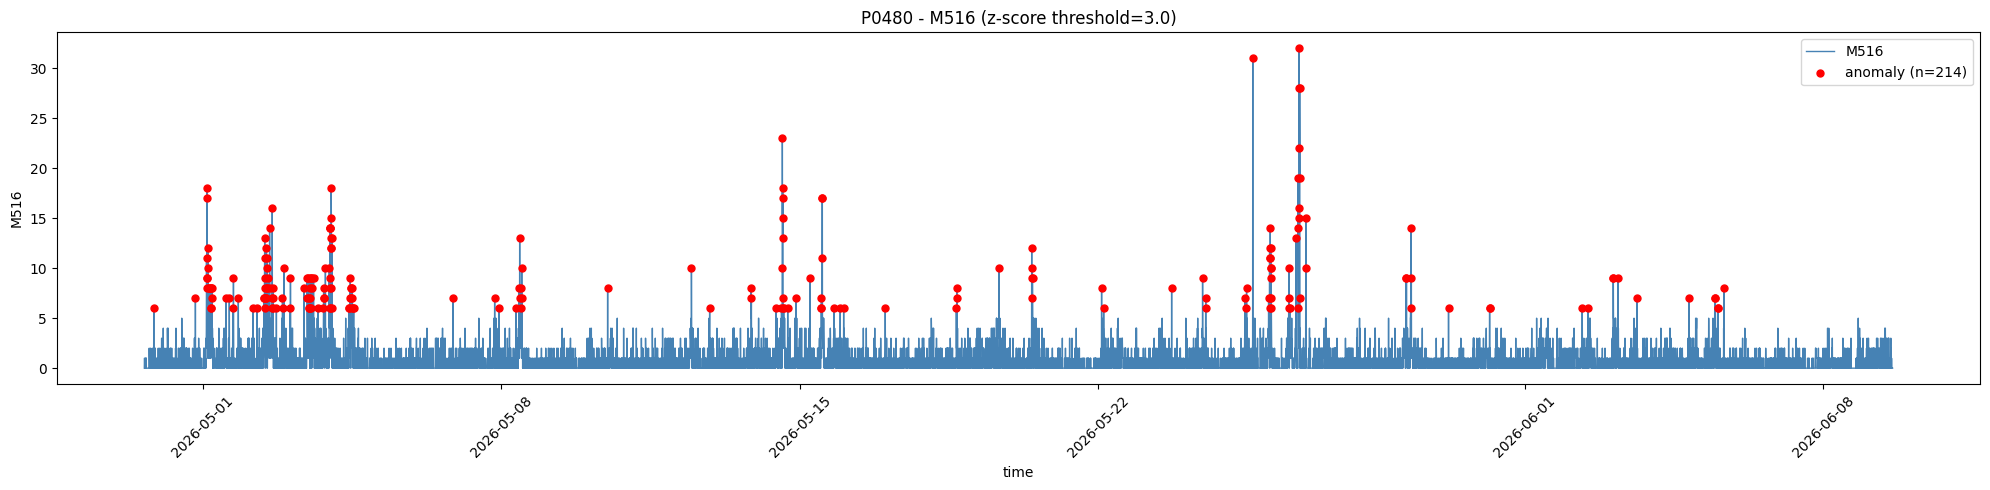

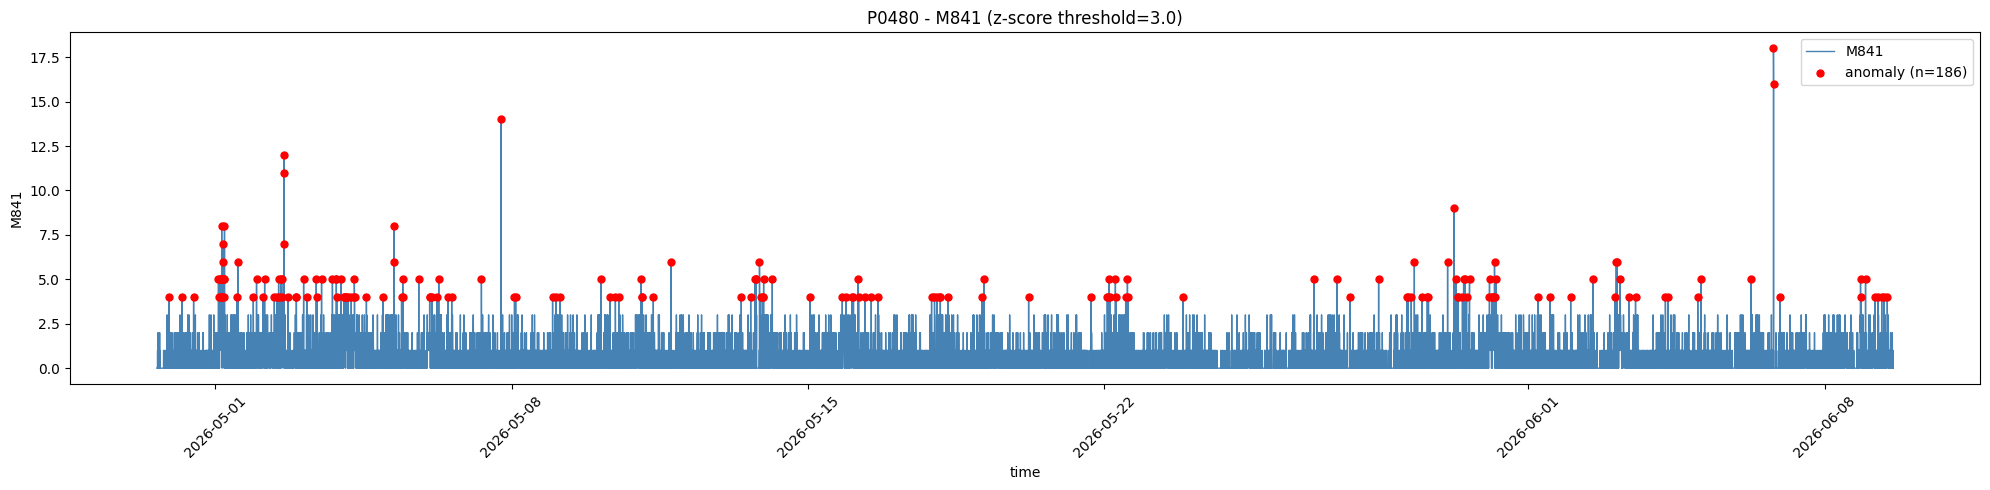

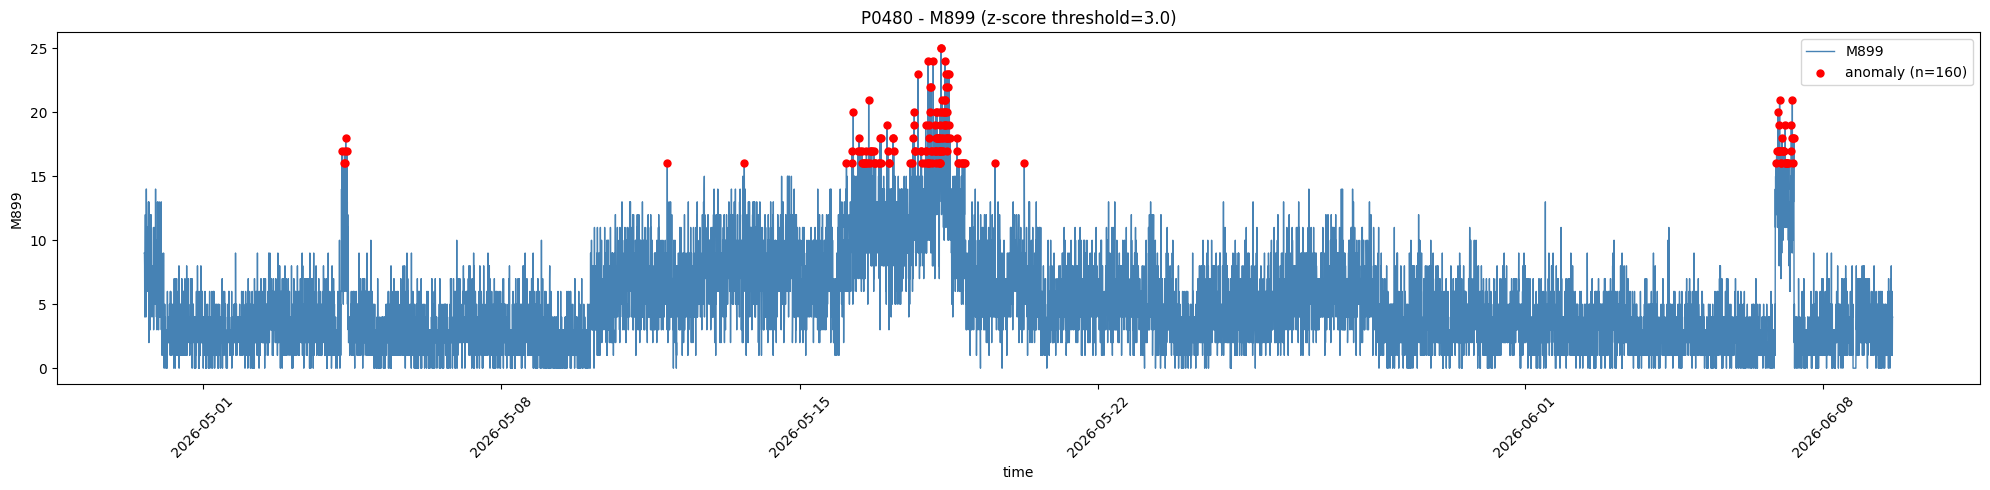

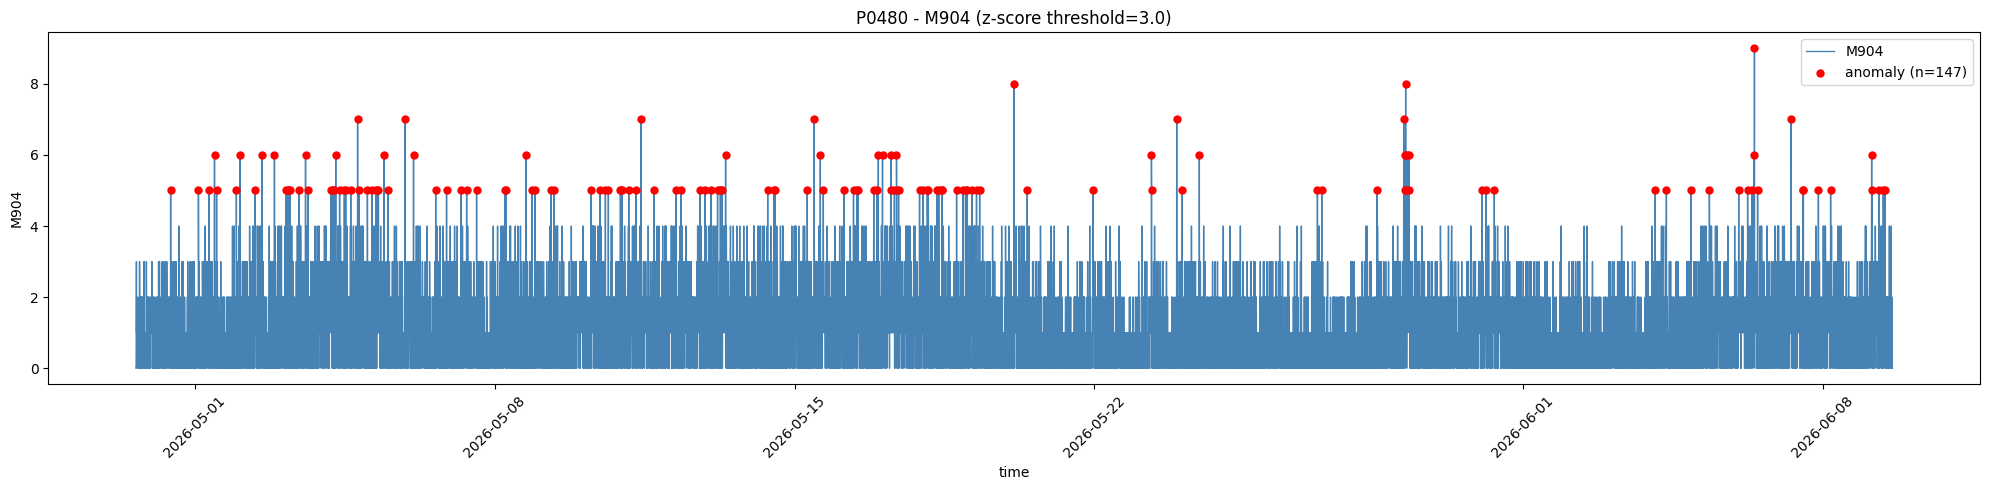

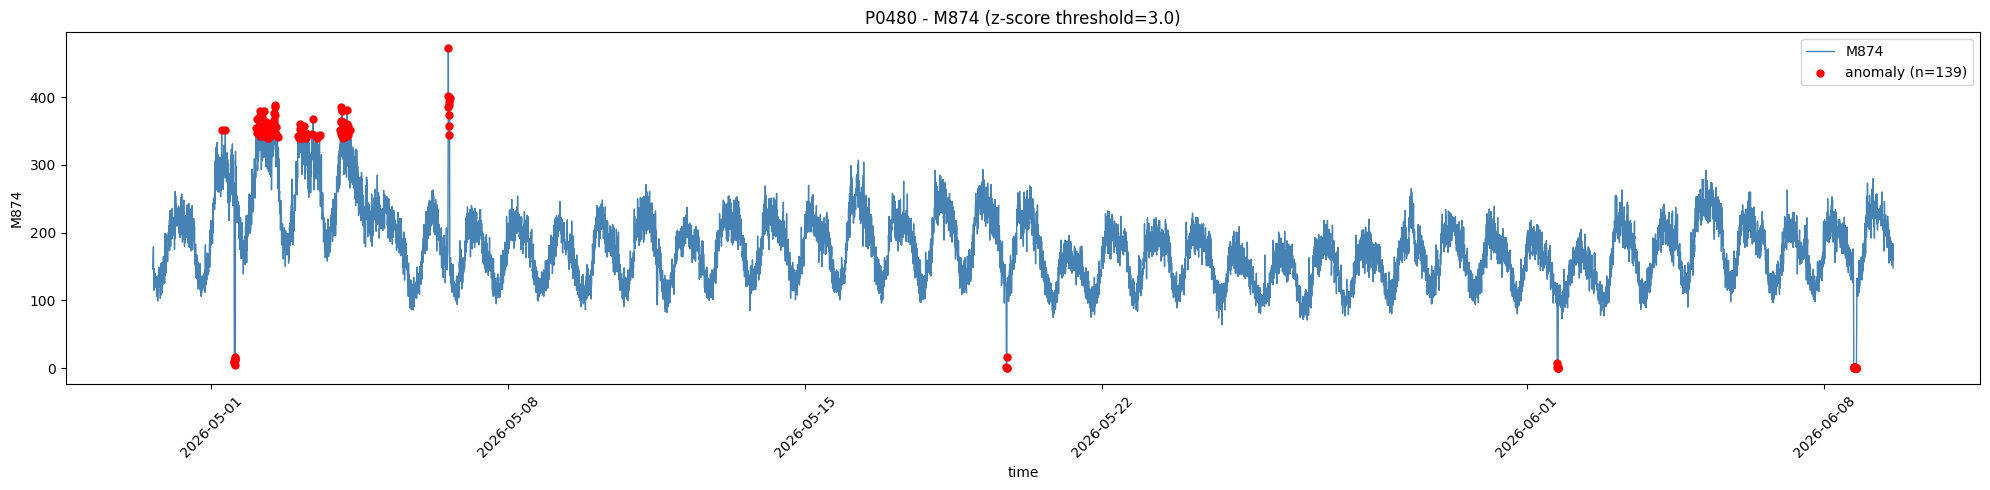

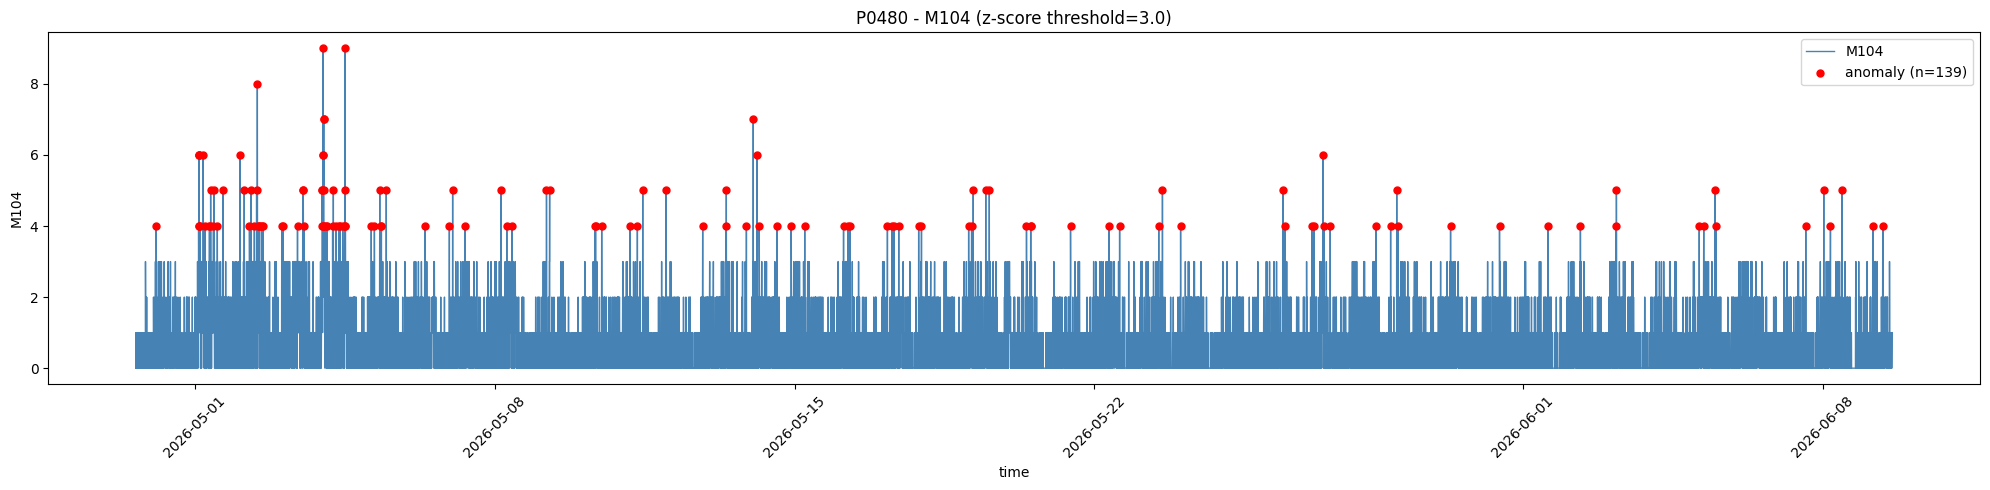

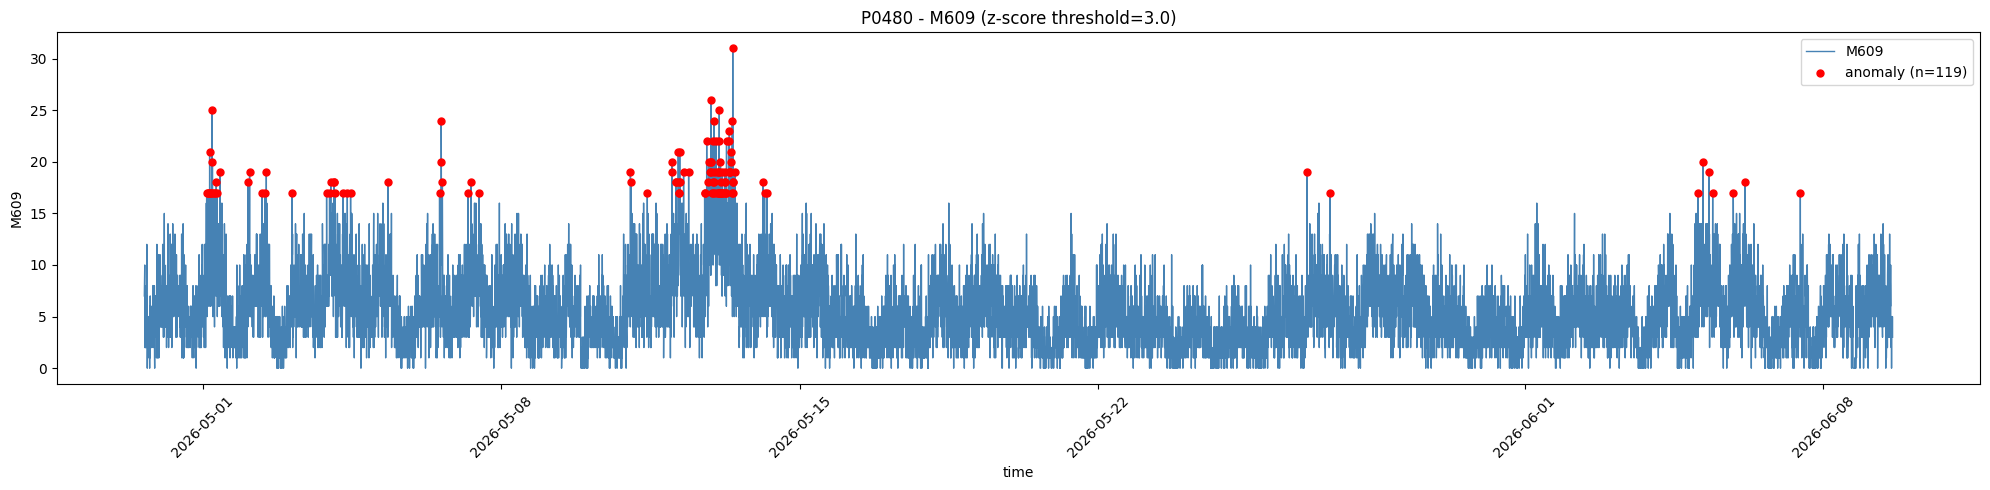

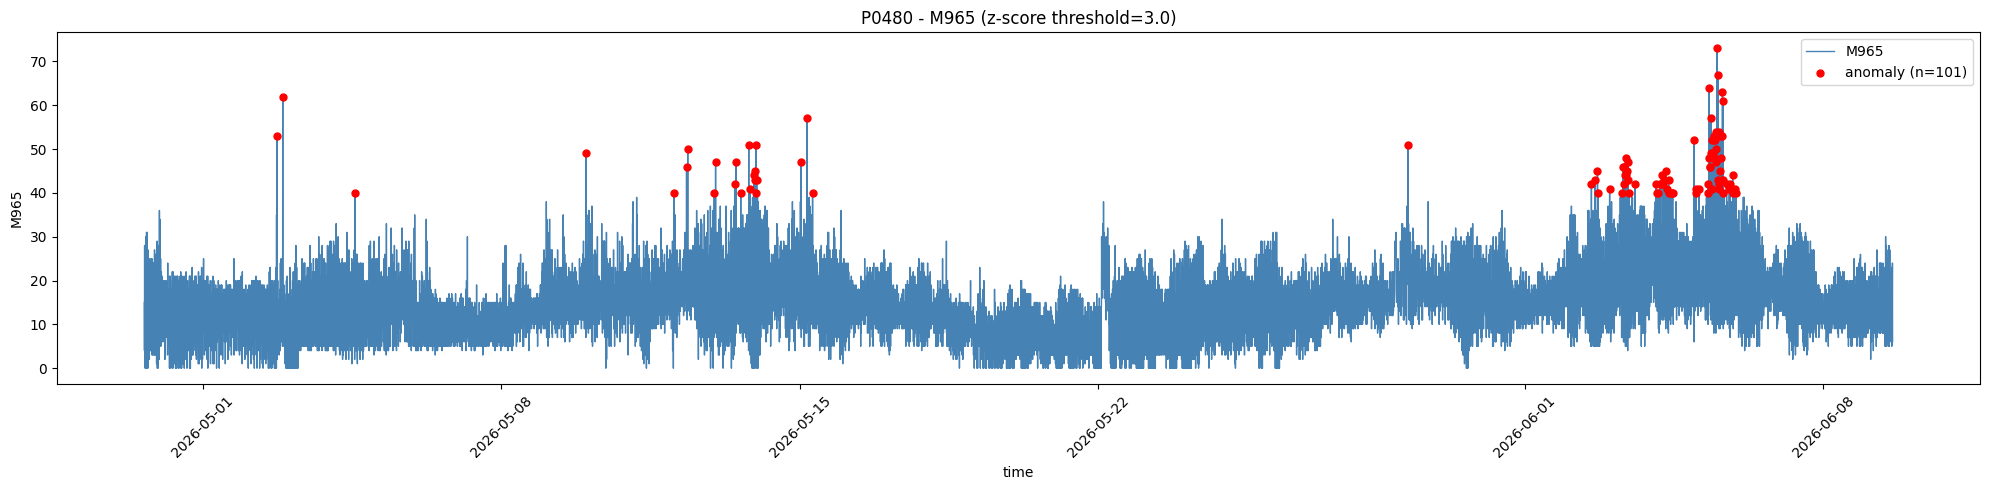

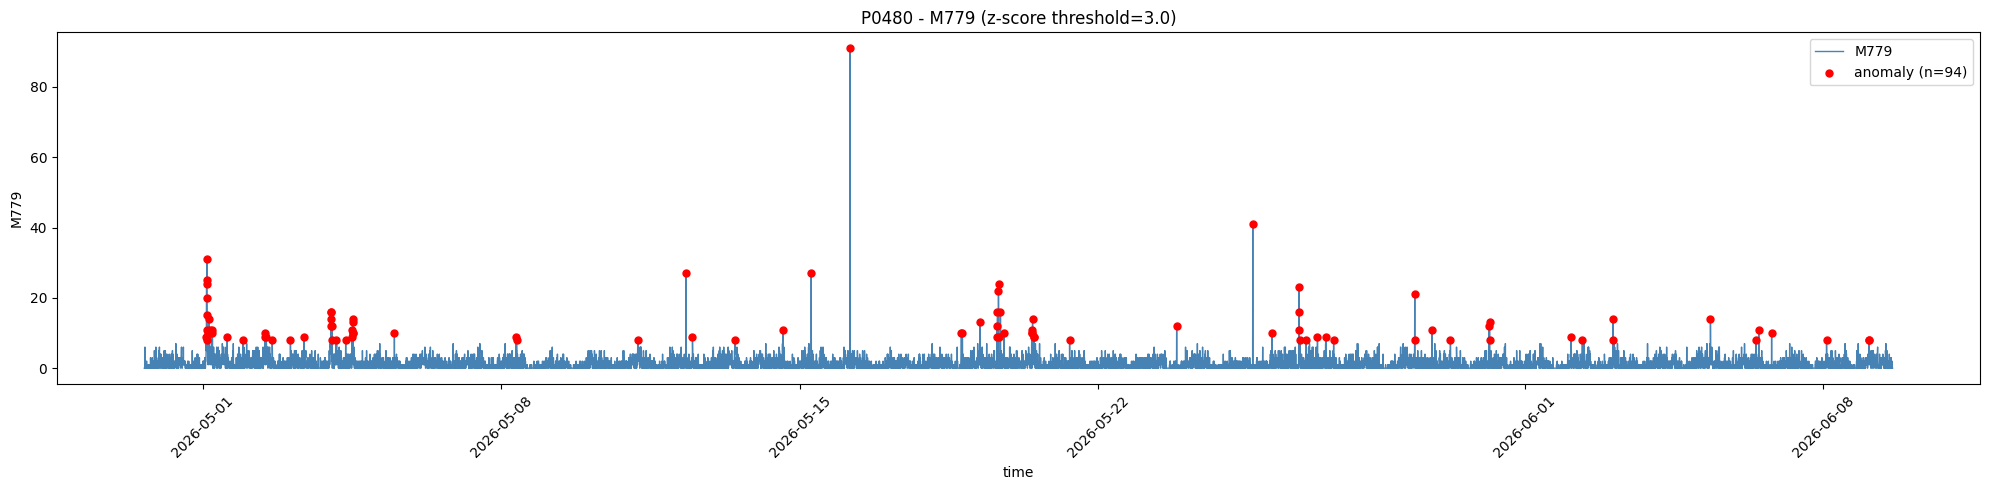

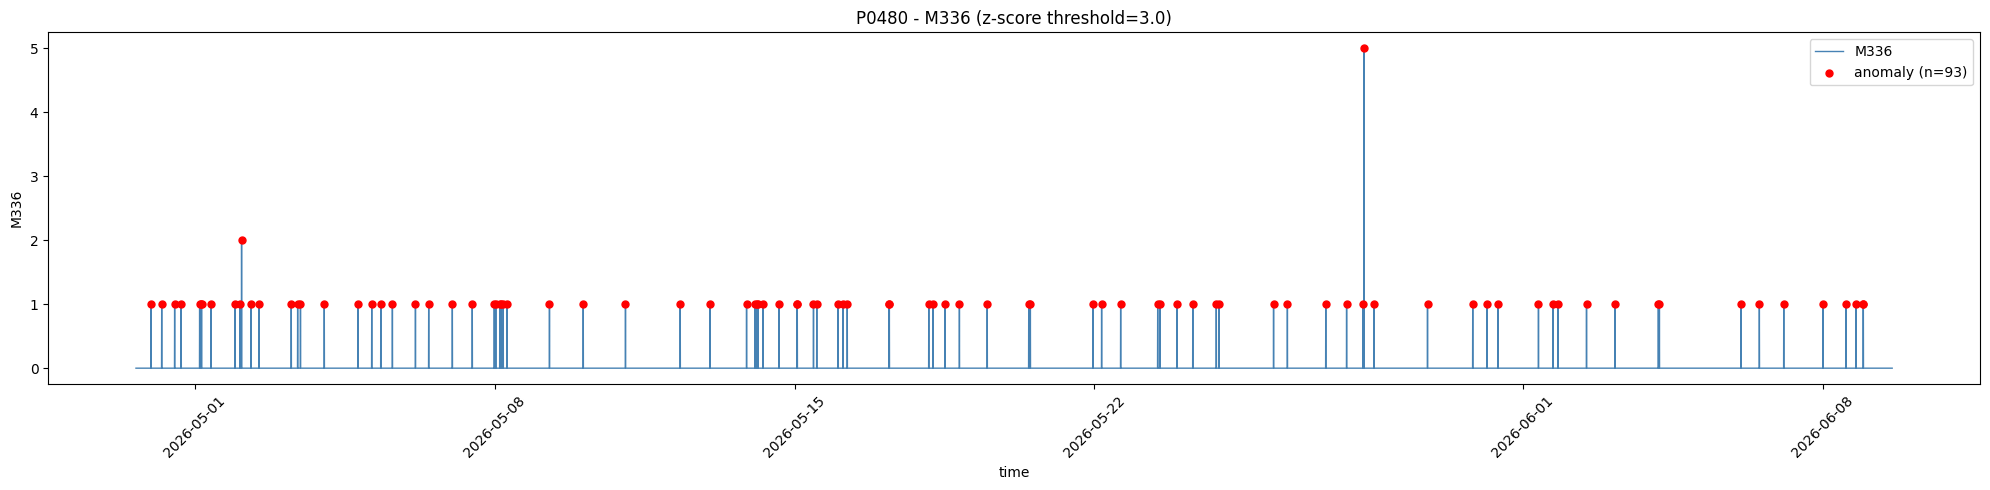

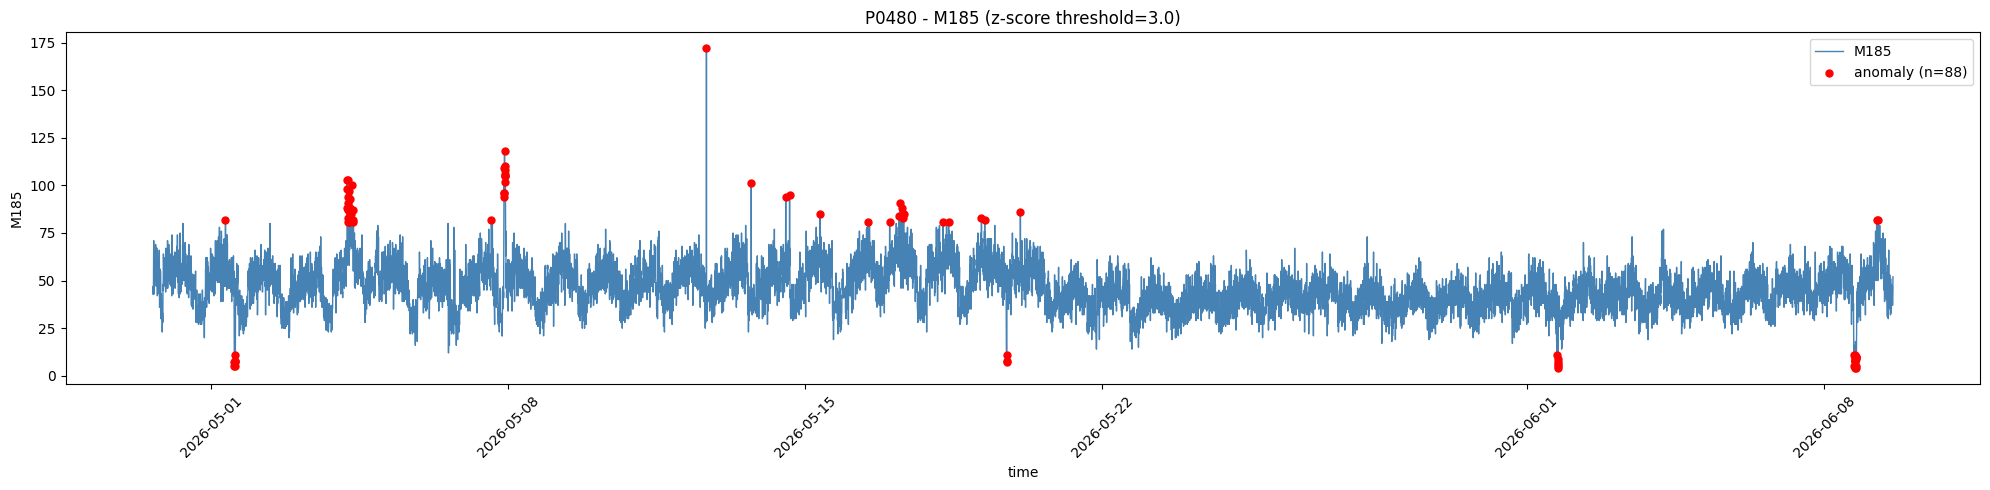

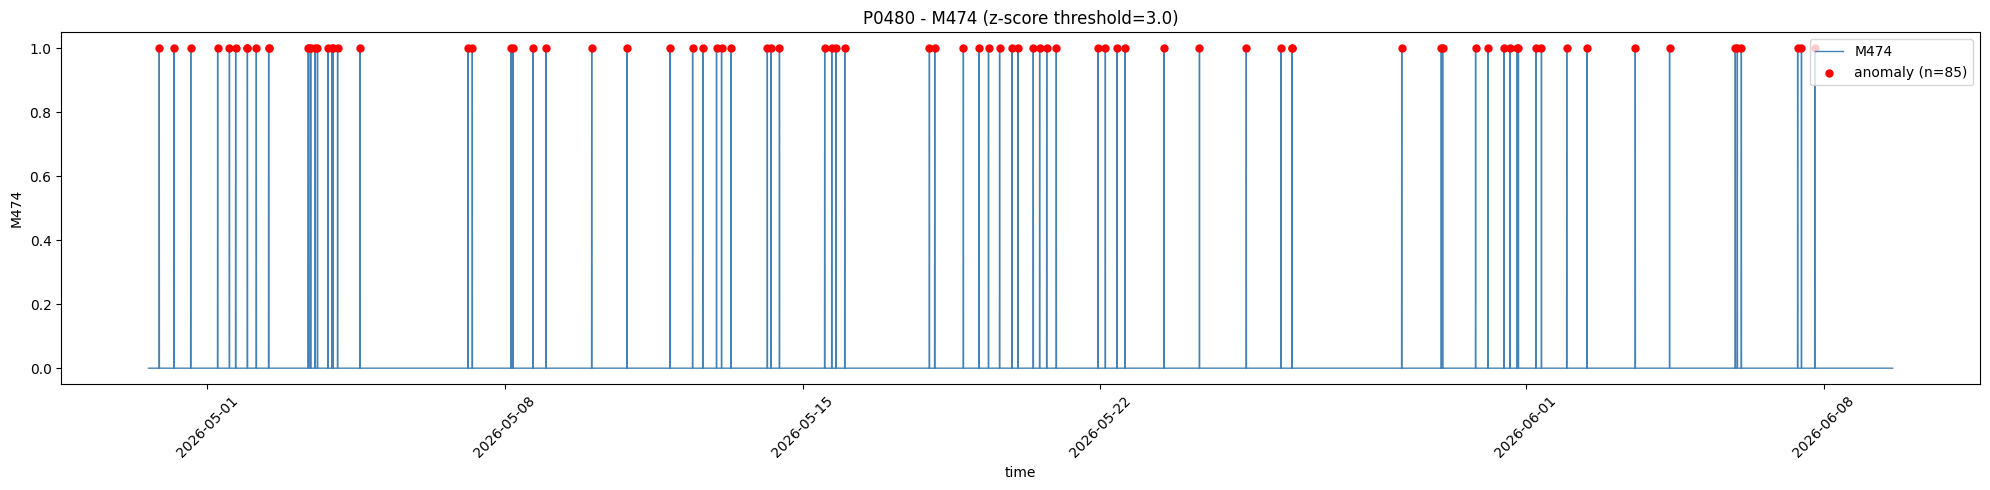

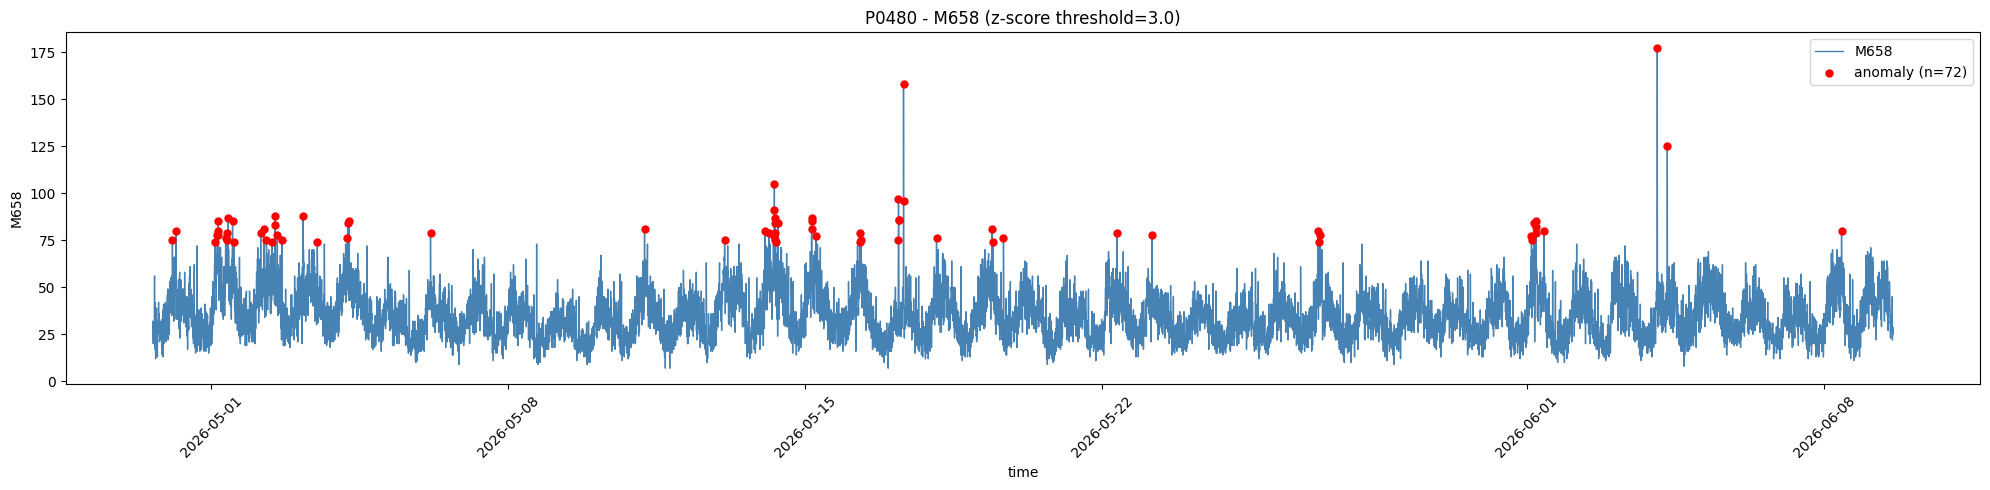

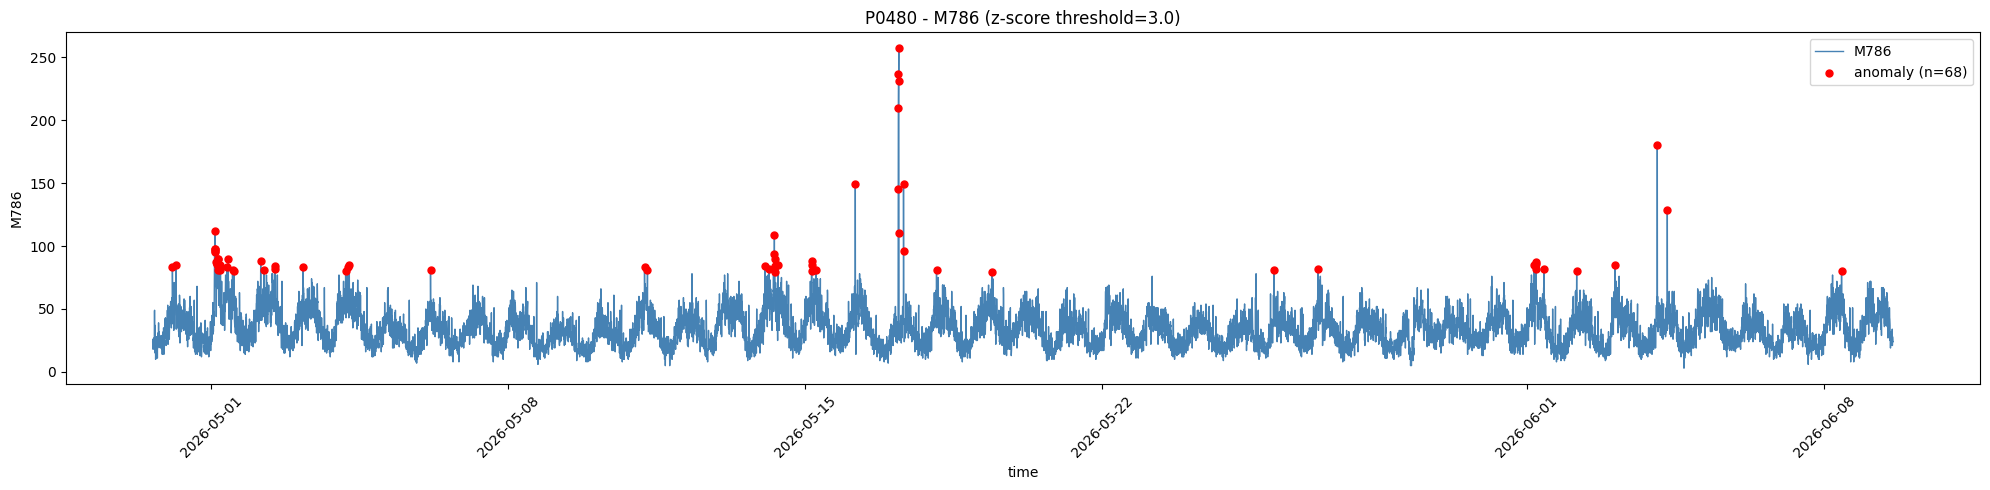

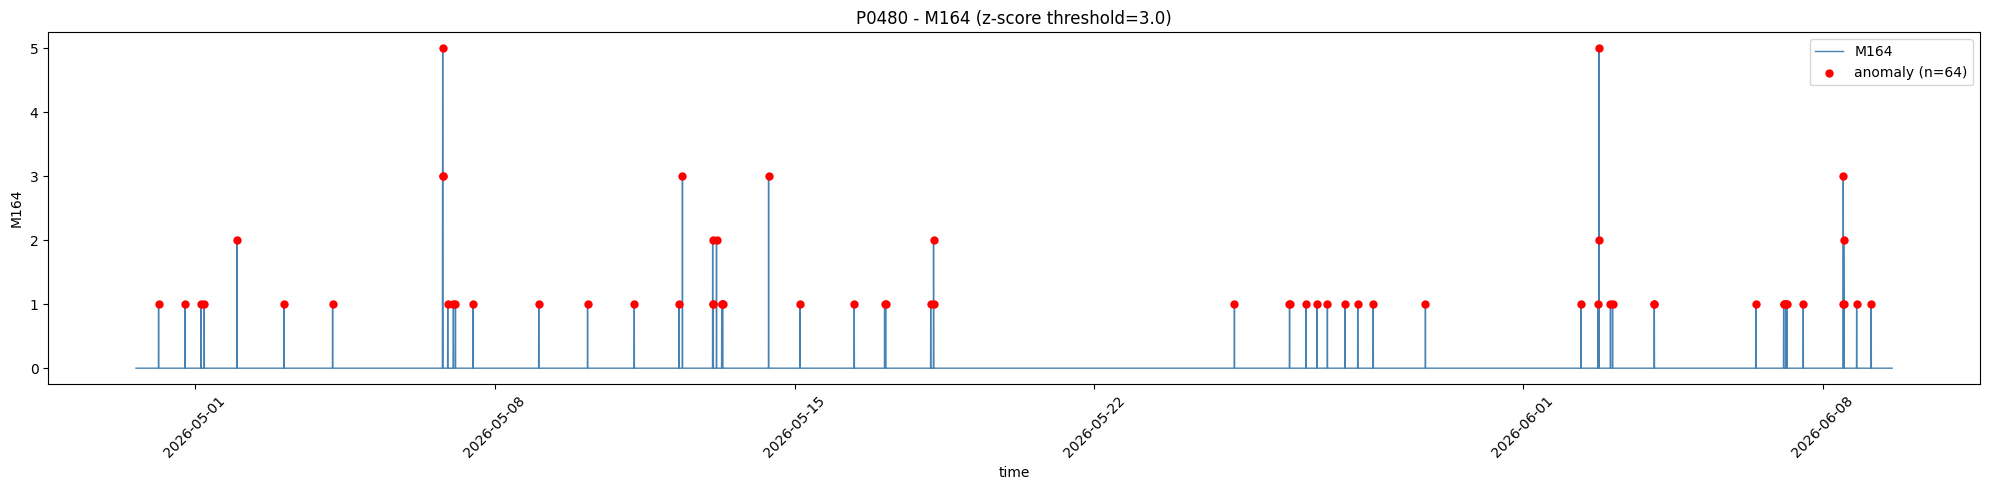

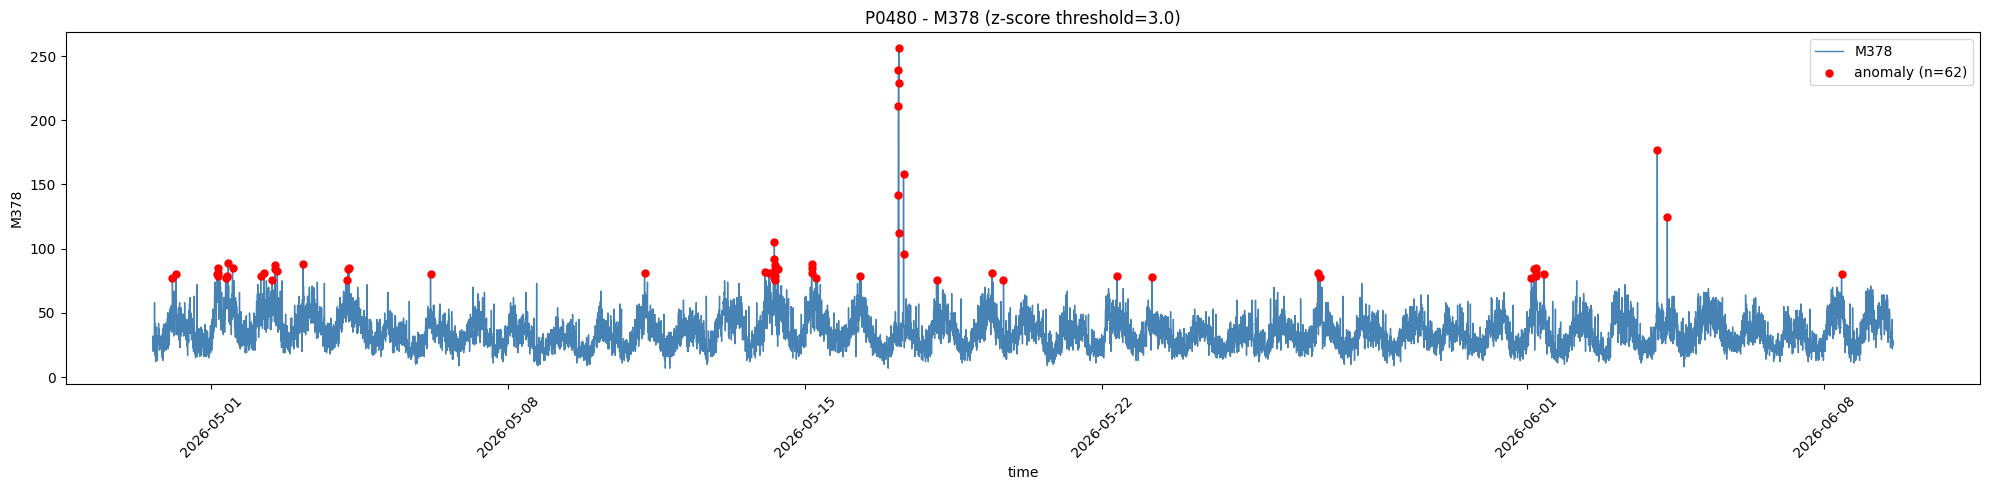

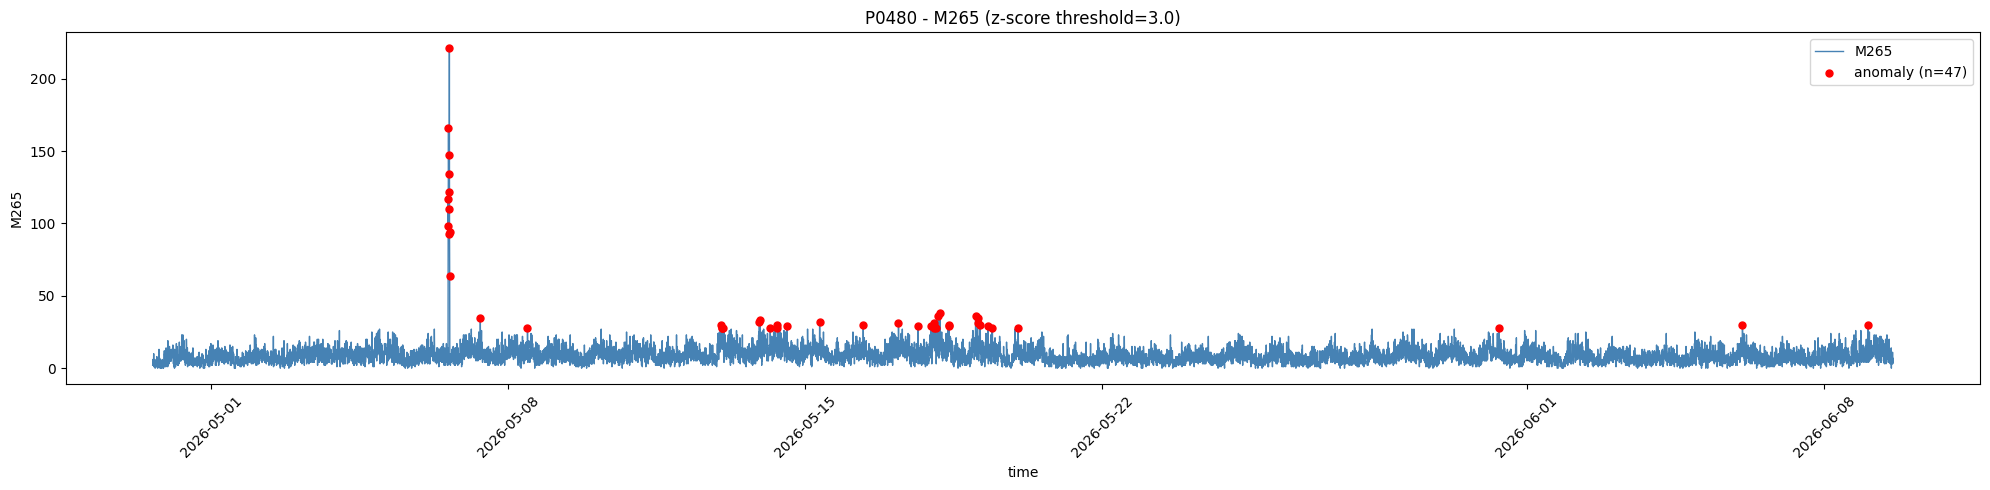

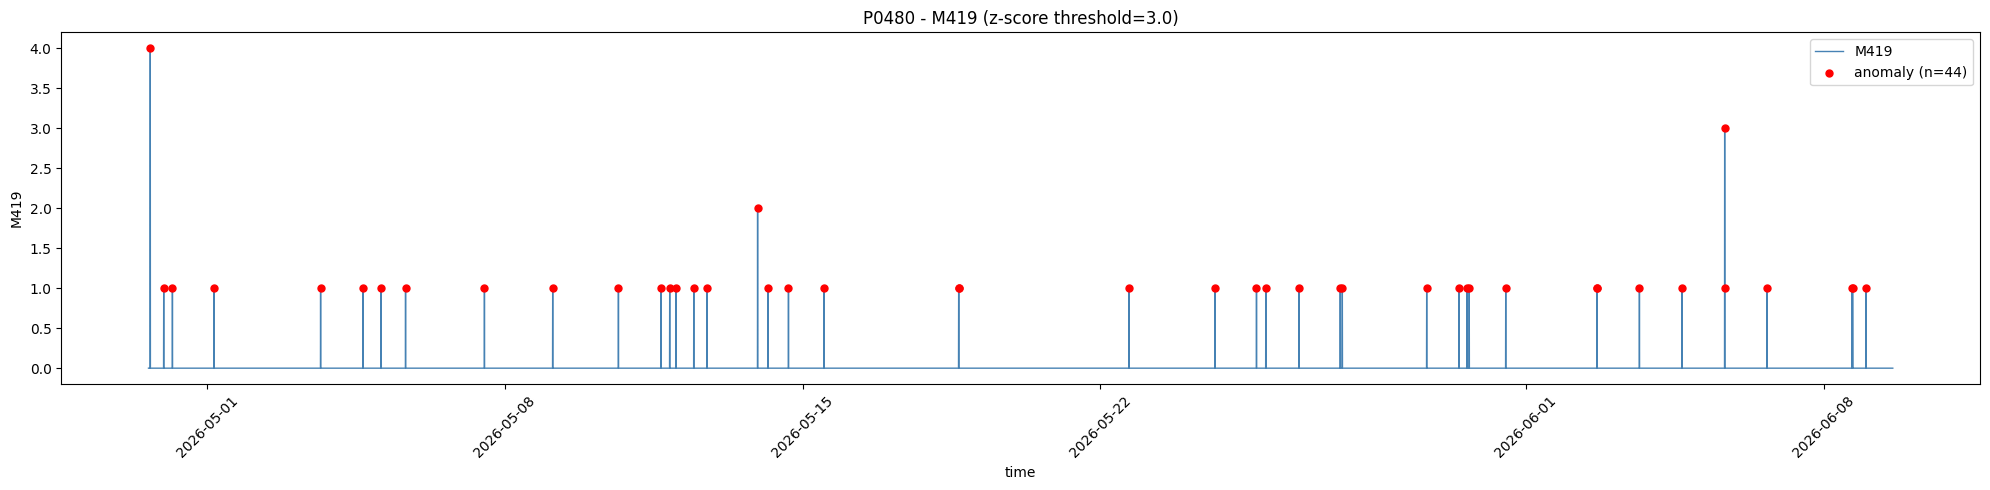

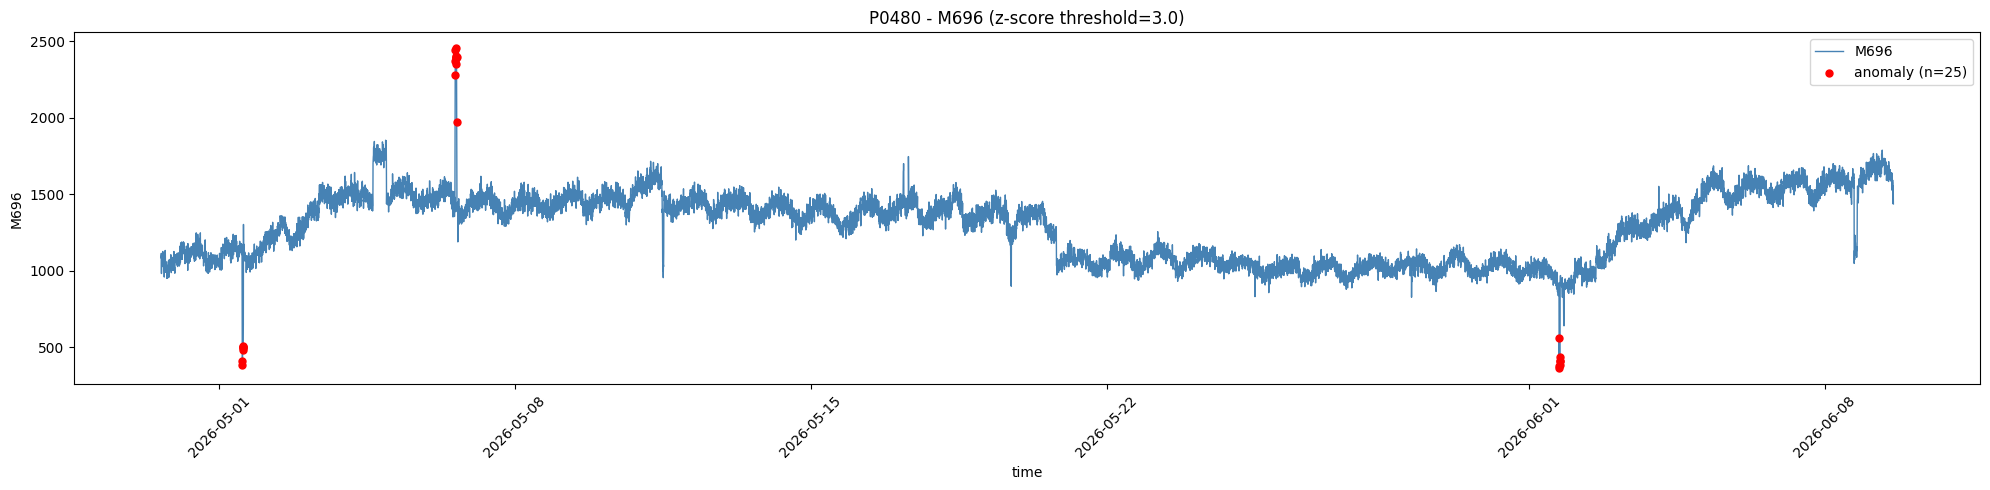

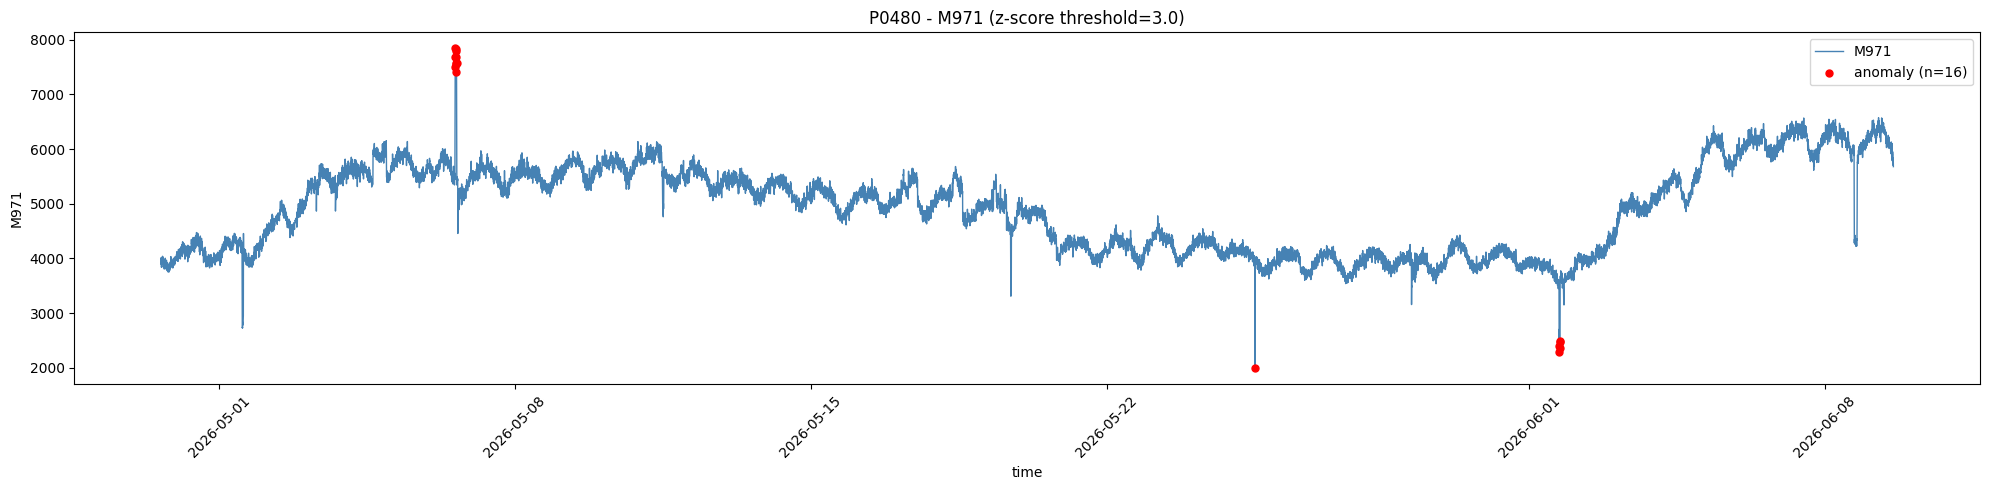

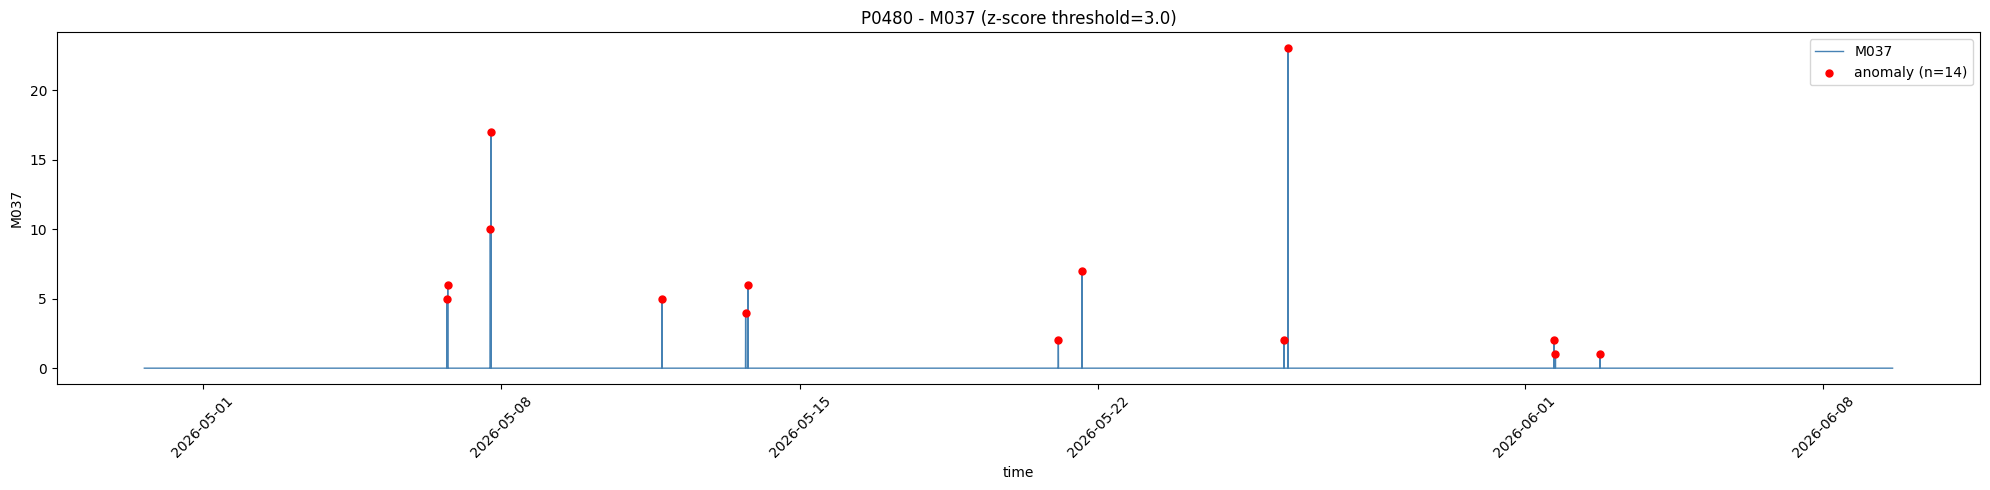

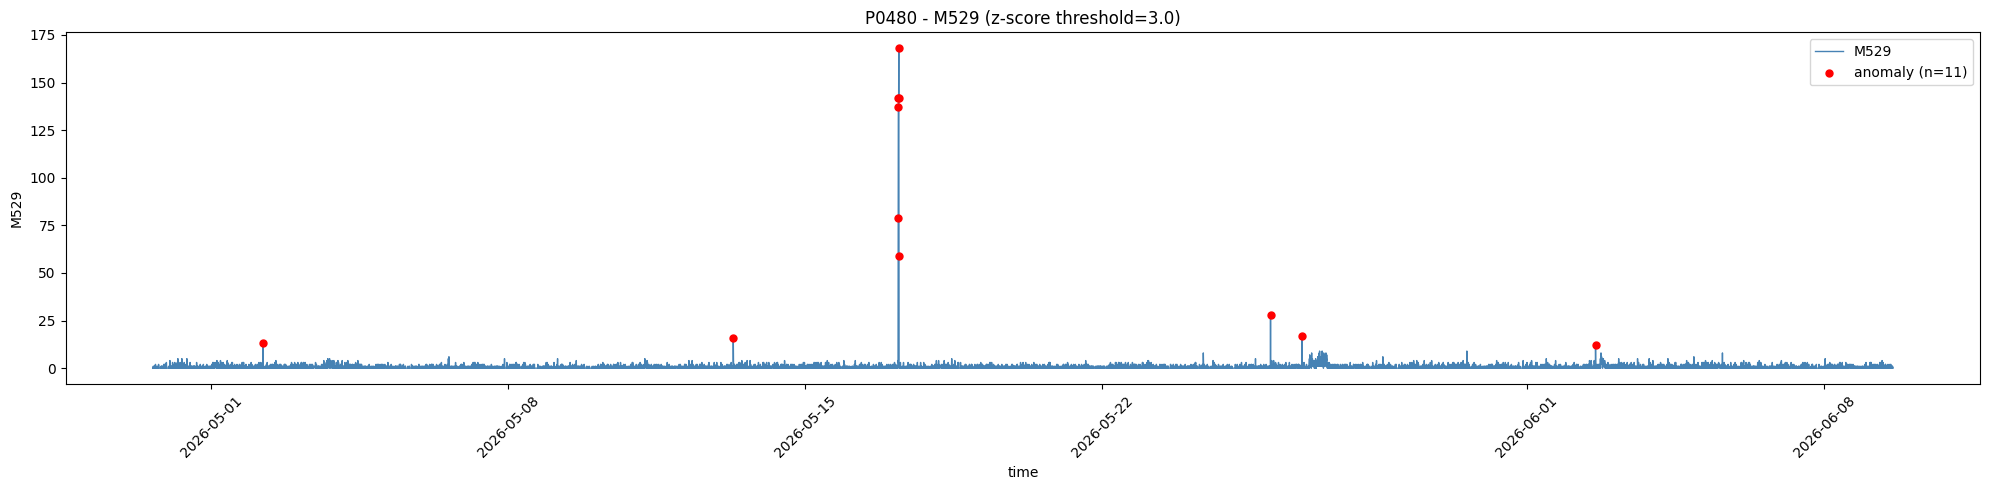

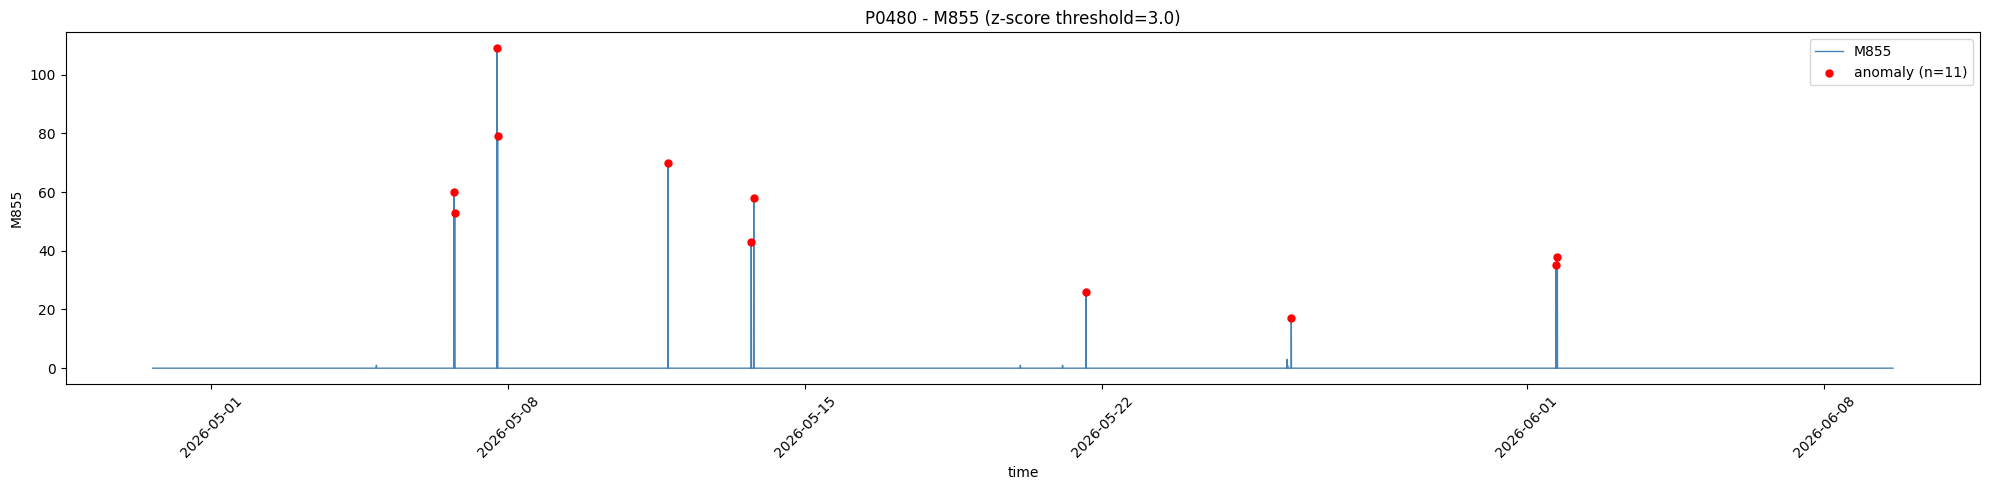

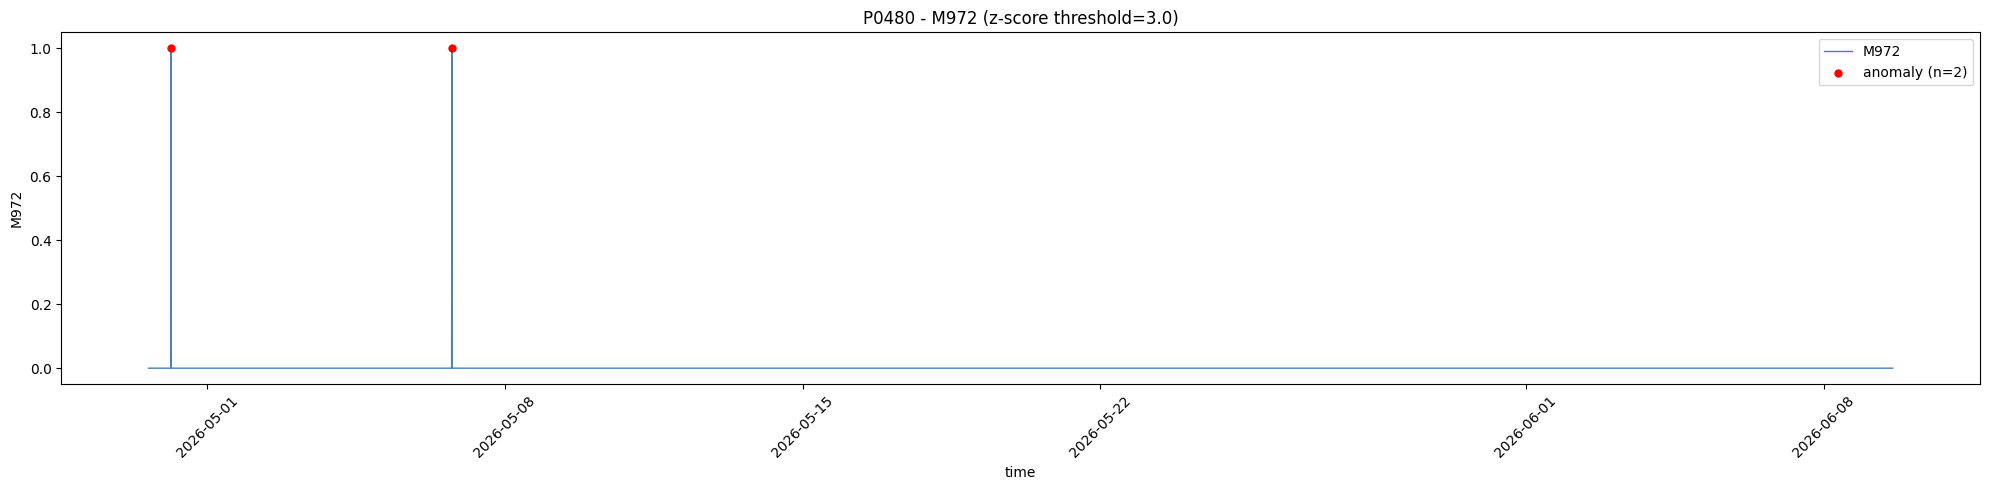

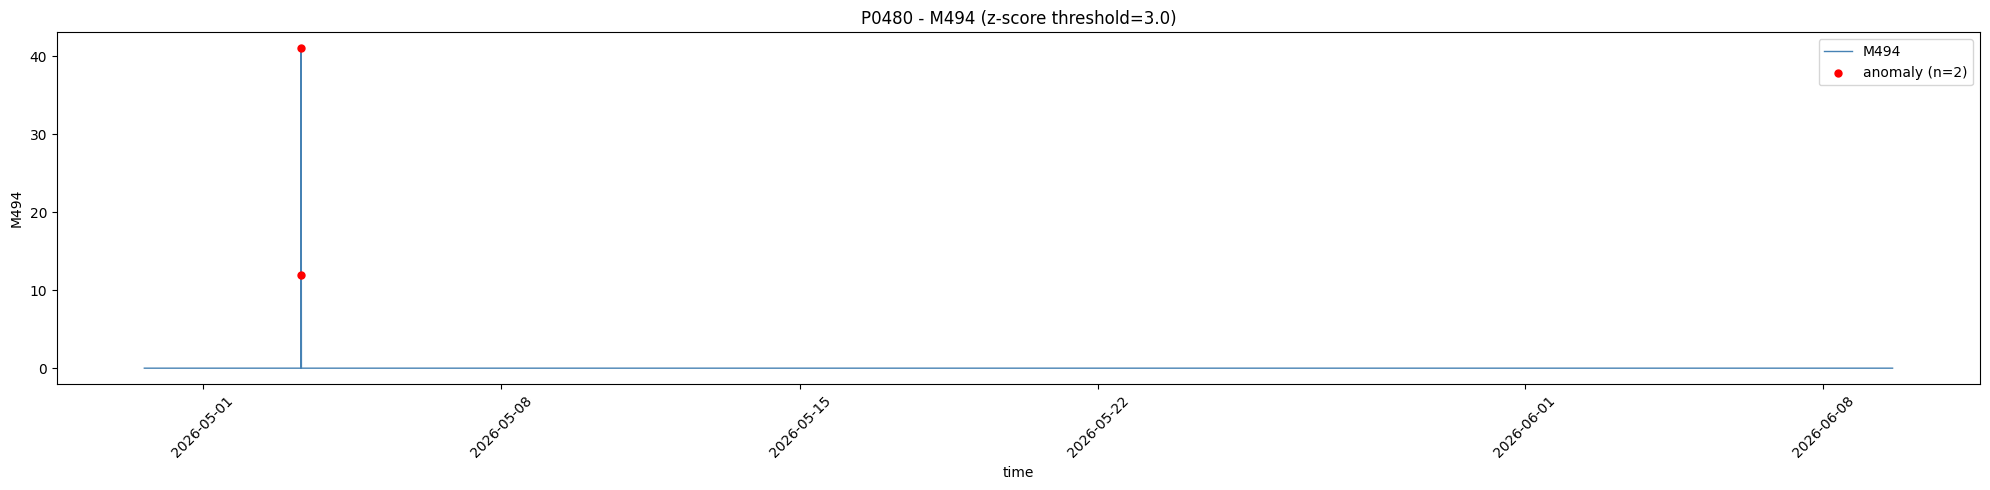

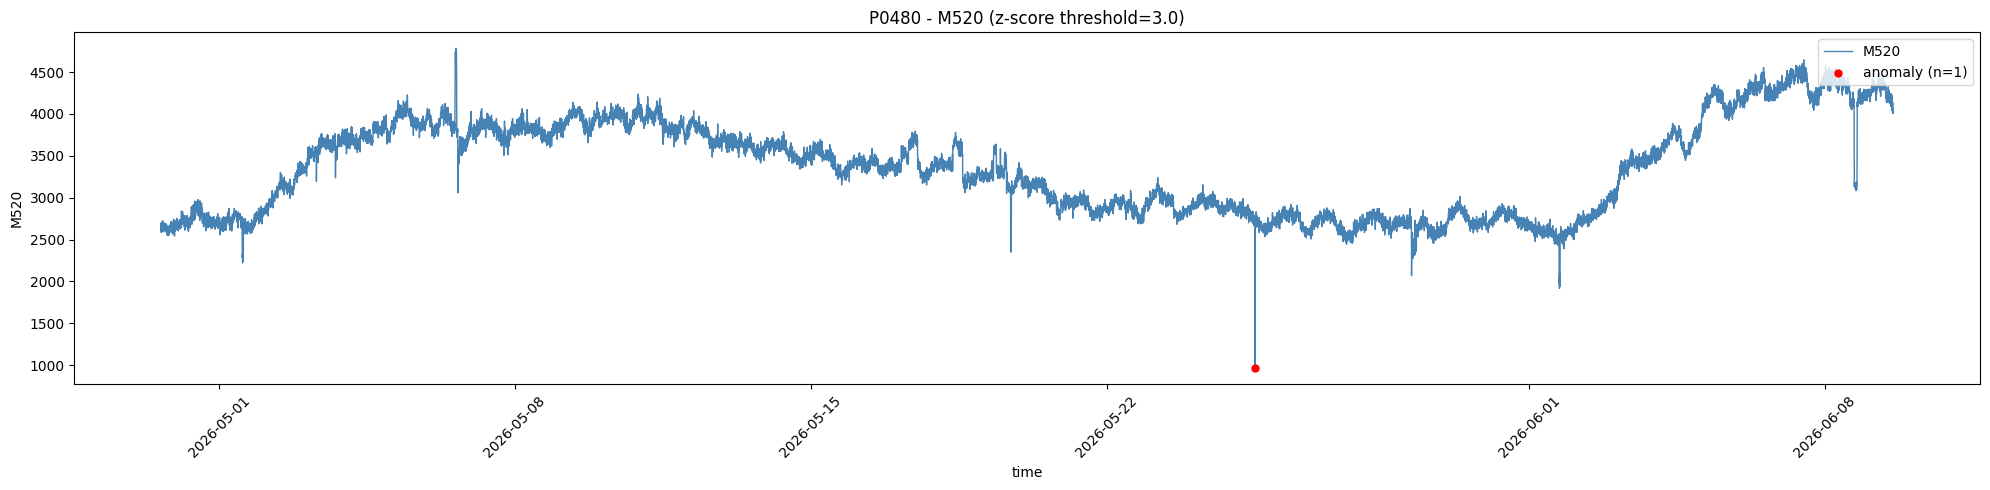

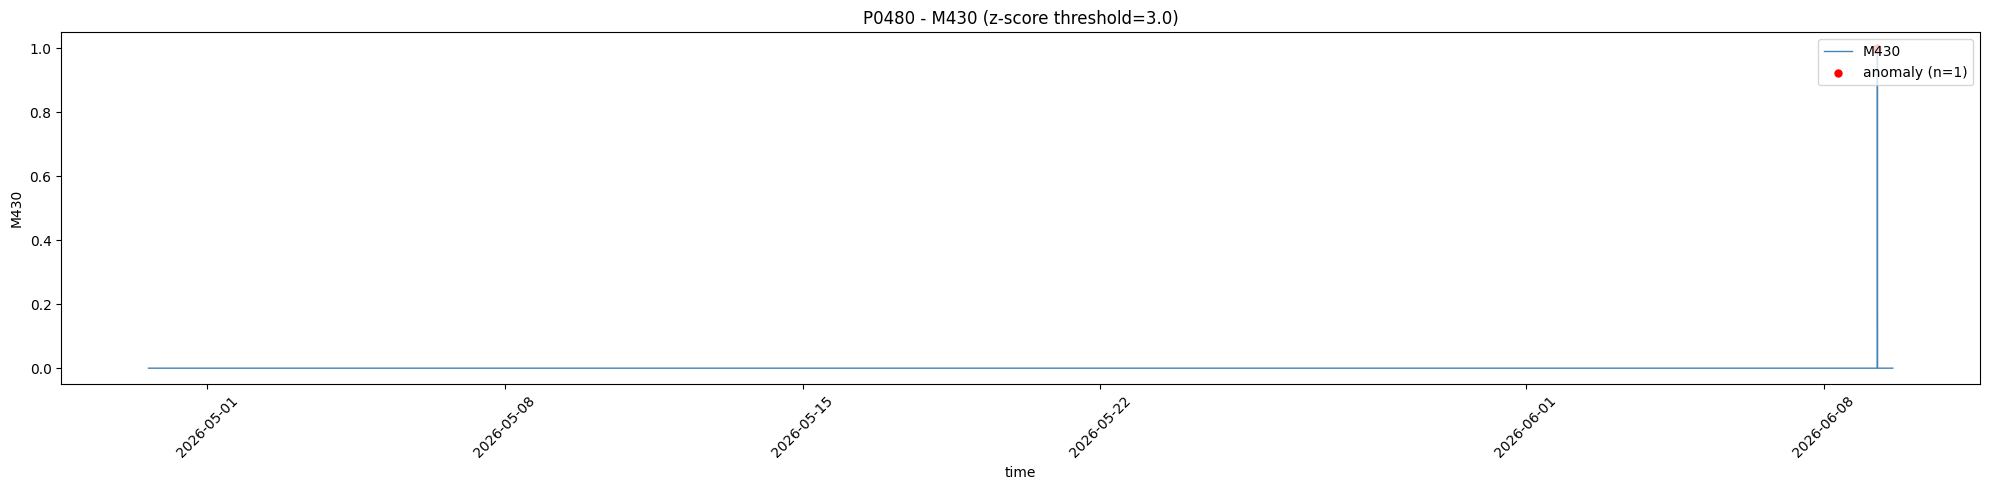

In [11]:
metrics_with_anomalies = anomaly_summary.loc[
    anomaly_summary["anomaly_count"] > 0, "metric"
].tolist()

print(f"anomaly가 있는 메트릭 수: {len(metrics_with_anomalies)}")

for col in metrics_with_anomalies:
    fig, ax = plt.subplots(figsize=(20, 5))

    ax.plot(df["time"], df[col], color="steelblue", linewidth=1.0, label=col)

    anomaly_idx = anomaly_mask.index[anomaly_mask[col]]
    ax.scatter(
        df.loc[anomaly_idx, "time"],
        df.loc[anomaly_idx, col],
        color="red",
        s=25,
        zorder=5,
        label=f"anomaly (n={anomaly_mask[col].sum()})",
    )

    ax.set_title(f"{TARGET_PLMN} - {col} (z-score threshold={Z_THRESHOLD})")
    ax.set_xlabel("time")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

## 5. 시점별 anomaly 발생 빈도

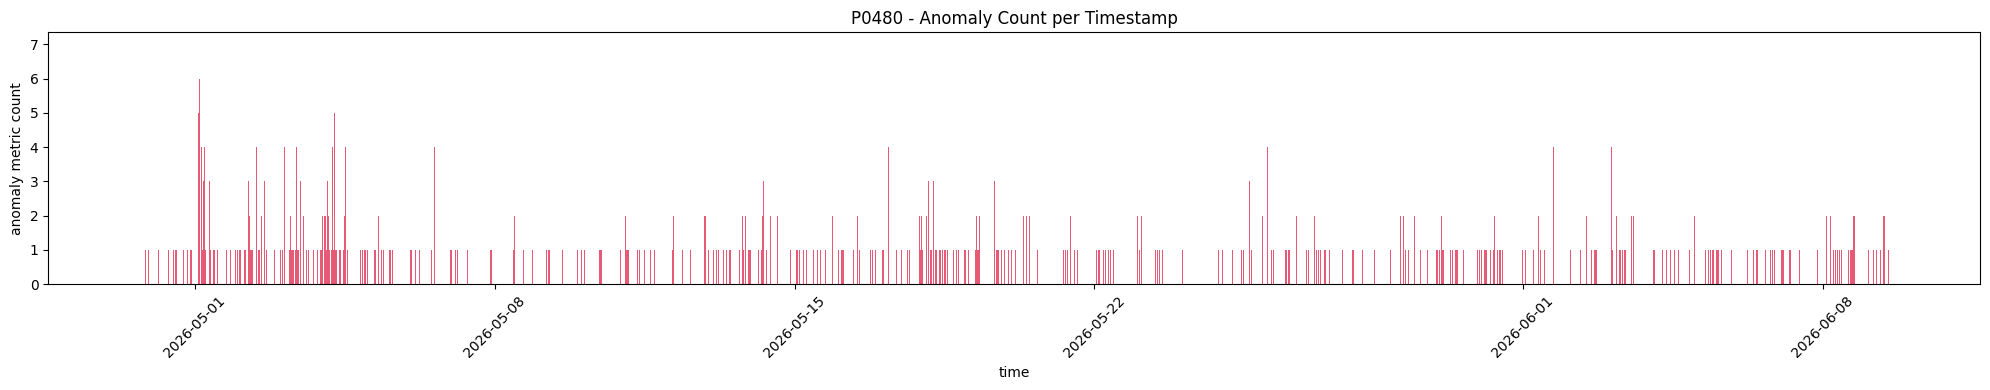

In [12]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.bar(df["time"], df["anomaly_count"], width=0.003, color="crimson", alpha=0.7)
ax.set_title(f"{TARGET_PLMN} - Anomaly Count per Timestamp")
ax.set_xlabel("time")
ax.set_ylabel("anomaly metric count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 6. Anomaly 상세 목록

In [14]:
anomaly_rows = []

for col in metric_cols:
    idx = anomaly_mask.index[anomaly_mask[col]]
    for i in idx:
        anomaly_rows.append(
            {
                "time": df.loc[i, "time"],
                "metric": col,
                "value": df.loc[i, col],
                "z_score": zscore_df.loc[i, col],
            }
        )

anomaly_detail = (
    pd.DataFrame(anomaly_rows)
    .sort_values(["time", "metric"])
    .reset_index(drop=True)
)

detail_csv_path = os.path.join(SAVE_DIR, f"{TARGET_PLMN}_zscore_anomalies.csv")
anomaly_detail.to_csv(detail_csv_path, index=False)

print(f"총 anomaly 레코드: {len(anomaly_detail):,}")
print(f"저장: {detail_csv_path}")
anomaly_detail.head(20)

총 anomaly 레코드: 3,947
저장: ../results/P0480_zscore_anomalies.csv


,time,metric,value,z_score
0,2026-04-29 15:55:00+00:00,M029,1,5.076172
1,2026-04-29 16:00:00+00:00,M419,4,51.968694
2,2026-04-29 17:25:00+00:00,M843,1,5.807053
3,2026-04-29 17:45:00+00:00,M490,1,3.628013
4,2026-04-29 17:55:00+00:00,M843,1,5.807053
5,2026-04-29 20:10:00+00:00,M029,1,5.076172
6,2026-04-29 20:20:00+00:00,M516,6,3.154183
7,2026-04-29 20:45:00+00:00,M736,2,3.639066
8,2026-04-29 21:05:00+00:00,M474,1,11.742332
9,2026-04-29 21:05:00+00:00,M490,1,3.628013
